In [1]:
import importlib
import sys
sys.path.append("/home/nichettg/Linux Programmi/Codici")

import numpy as np
import funzioni as f
importlib.reload(f)

import matplotlib.pyplot as plt
import grafici as gf
importlib.reload(gf)

import json

# 1. Raccolta dati

Lettura dati nel file JavaScript config.json

In [2]:
with open("config.json", "r") as file:
    config = json.load(file)

v_min = config["zoom_min"]
v_max = config["zoom_max"]
estremo = config["tolleranza"]
sx = config["Risoluzione_P"] / np.sqrt(12)
sy = config["Risoluzione_V"] / np.sqrt(12)
ls3 = config["MinimiQuadrati3"]

Funzione conversione unità di misura

In [3]:
def converti(P_kgcm2, V_cm3, T_C):
    
    # 1 kg/cm² = 98_066.5 Pa
    P_Pa = 98066.5 * P_kgcm2
    # 1 cm³ = 1e6 m³
    V_m3 = 1e-6 * V_cm3
    # °C to K
    T_K = T_C + 273.15

    return P_Pa, V_m3, T_K

Lettura dati cartella Data

In [4]:
import os

input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati,dati_completi = {}, {}

for i, input_file in enumerate(input_files):
    array = np.loadtxt(input_file)
    P, V, T = array[:, 0], array[:, 1], array[:, 2]

    dati_completi[f"{(i+1)*10+5}"] = {"P": P.copy(), "V": V.copy(), "T": T.copy()}

    index = np.argmin(V)

    comp = {"P": P[:index], "V": V[:index], "T": T[:index]}
    exp  = {"P": P[index:], "V": V[index:], "T": T[index:]}

    dati[f"{(i+1)*10+5}"] = {
        "compressione": {chiave: variabile[ (comp['V'] > v_min) & (comp['V'] < v_max) ] for chiave,variabile in comp.items()},  # variabili sono P,V,T
        "espansione": {chiave: variabile[ (exp['V'] > v_min) & (exp['V'] < v_max) ] for chiave,variabile in exp.items()}
    }

Tabella di controllo

In [5]:
import pandas as pd
df = pd.DataFrame(dati)
print(df)

                                                             15  \
compressione  {'P': [1.282, 1.283, 1.285, 1.285, 1.286, 1.28...   
espansione    {'P': [2.592, 2.578, 2.575, 2.573, 2.57, 2.565...   

                                                             25  \
compressione  {'P': [1.316, 1.316, 1.316, 1.317, 1.317, 1.31...   
espansione    {'P': [2.656, 2.649, 2.643, 2.637, 2.63, 2.624...   

                                                             35  \
compressione  {'P': [1.362, 1.363, 1.363, 1.364, 1.365, 1.36...   
espansione    {'P': [2.798, 2.794, 2.79, 2.786, 2.781, 2.776...   

                                                             45  \
compressione  {'P': [1.407, 1.407, 1.408, 1.409, 1.409, 1.40...   
espansione    {'P': [2.881, 2.878, 2.877, 2.877, 2.877, 2.87...   

                                                             55  
compressione  {'P': [1.446, 1.446, 1.446, 1.446, 1.447, 1.44...  
espansione    {'P': [2.764, 2.76, 2.759, 2.759, 2.76, 2.759,

# 2. Fit lineare volume e grafici

In [6]:
directory = "Originali"

Regressione lineare (Minimi quadrati III opzionali)

In [7]:
def regressione(dizionario, directory, input_files):
    parametri = {}

    # sx e sy sono quelle definite in config.json

    for i, (temp, serie) in enumerate(dizionario.items()):
        parametri[temp] = {}
        for fase_chiave, fase in serie.items():
            output_filename = input_files[i].replace( "Data", "Elaborati/" + directory + "/").replace( "GR03_", "").replace( ".txt", f"_{fase_chiave}.txt") 
            a,b,sa,sb,cov,p,errpost = f.elaborato(1/fase["P"], fase["V"], sy, output_filename, int(temp)-1 , sx/(fase["P"]**2), ritorno = True)
            parametri[temp][fase_chiave] = {
                "a": a, "b": b, "sa": sa, "sb": sb, "cov": cov, "p": p, "errpost": errpost
            }
    return parametri

In [8]:
parametri = regressione(dati, directory, input_files)


Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3


Tabella di controllo

In [9]:
df = pd.DataFrame(parametri)
print(df)

                                                             15  \
compressione  {'a': -1.214838018858779, 'b': 27.086219870031...   
espansione    {'a': -1.880574678392969, 'b': 27.642181054239...   

                                                             25  \
compressione  {'a': -1.839456340507699, 'b': 28.667359017261...   
espansione    {'a': -1.9185399233488878, 'b': 28.54495756638...   

                                                             35  \
compressione  {'a': -1.240143825049799, 'b': 28.895738019166...   
espansione    {'a': -1.3182402129495312, 'b': 28.79260002440...   

                                                             45  \
compressione  {'a': -1.2477820897966685, 'b': 29.83839165092...   
espansione    {'a': -1.4779460426085222, 'b': 29.92106353010...   

                                                             55  
compressione  {'a': -2.91345085979312, 'b': 33.0208906190631...  
espansione    {'a': -3.4643728197318264, 'b': 33.53029917566

## 2.1 Grafici

In [10]:
def darken(color, factor=0.6):
    return tuple(factor * c for c in color)

In [11]:
import itertools

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_cycle_fisso = itertools.cycle(colors)

cmap = plt.get_cmap('tab10')
color_cycle = itertools.cycle(cmap.colors)

markers = ['o','s','^','D','v']
marker_cycle = itertools.cycle(markers)

errori = gf.default_error_params()
gf.imposta_stile_globale()

### 2.1.1 Confronto

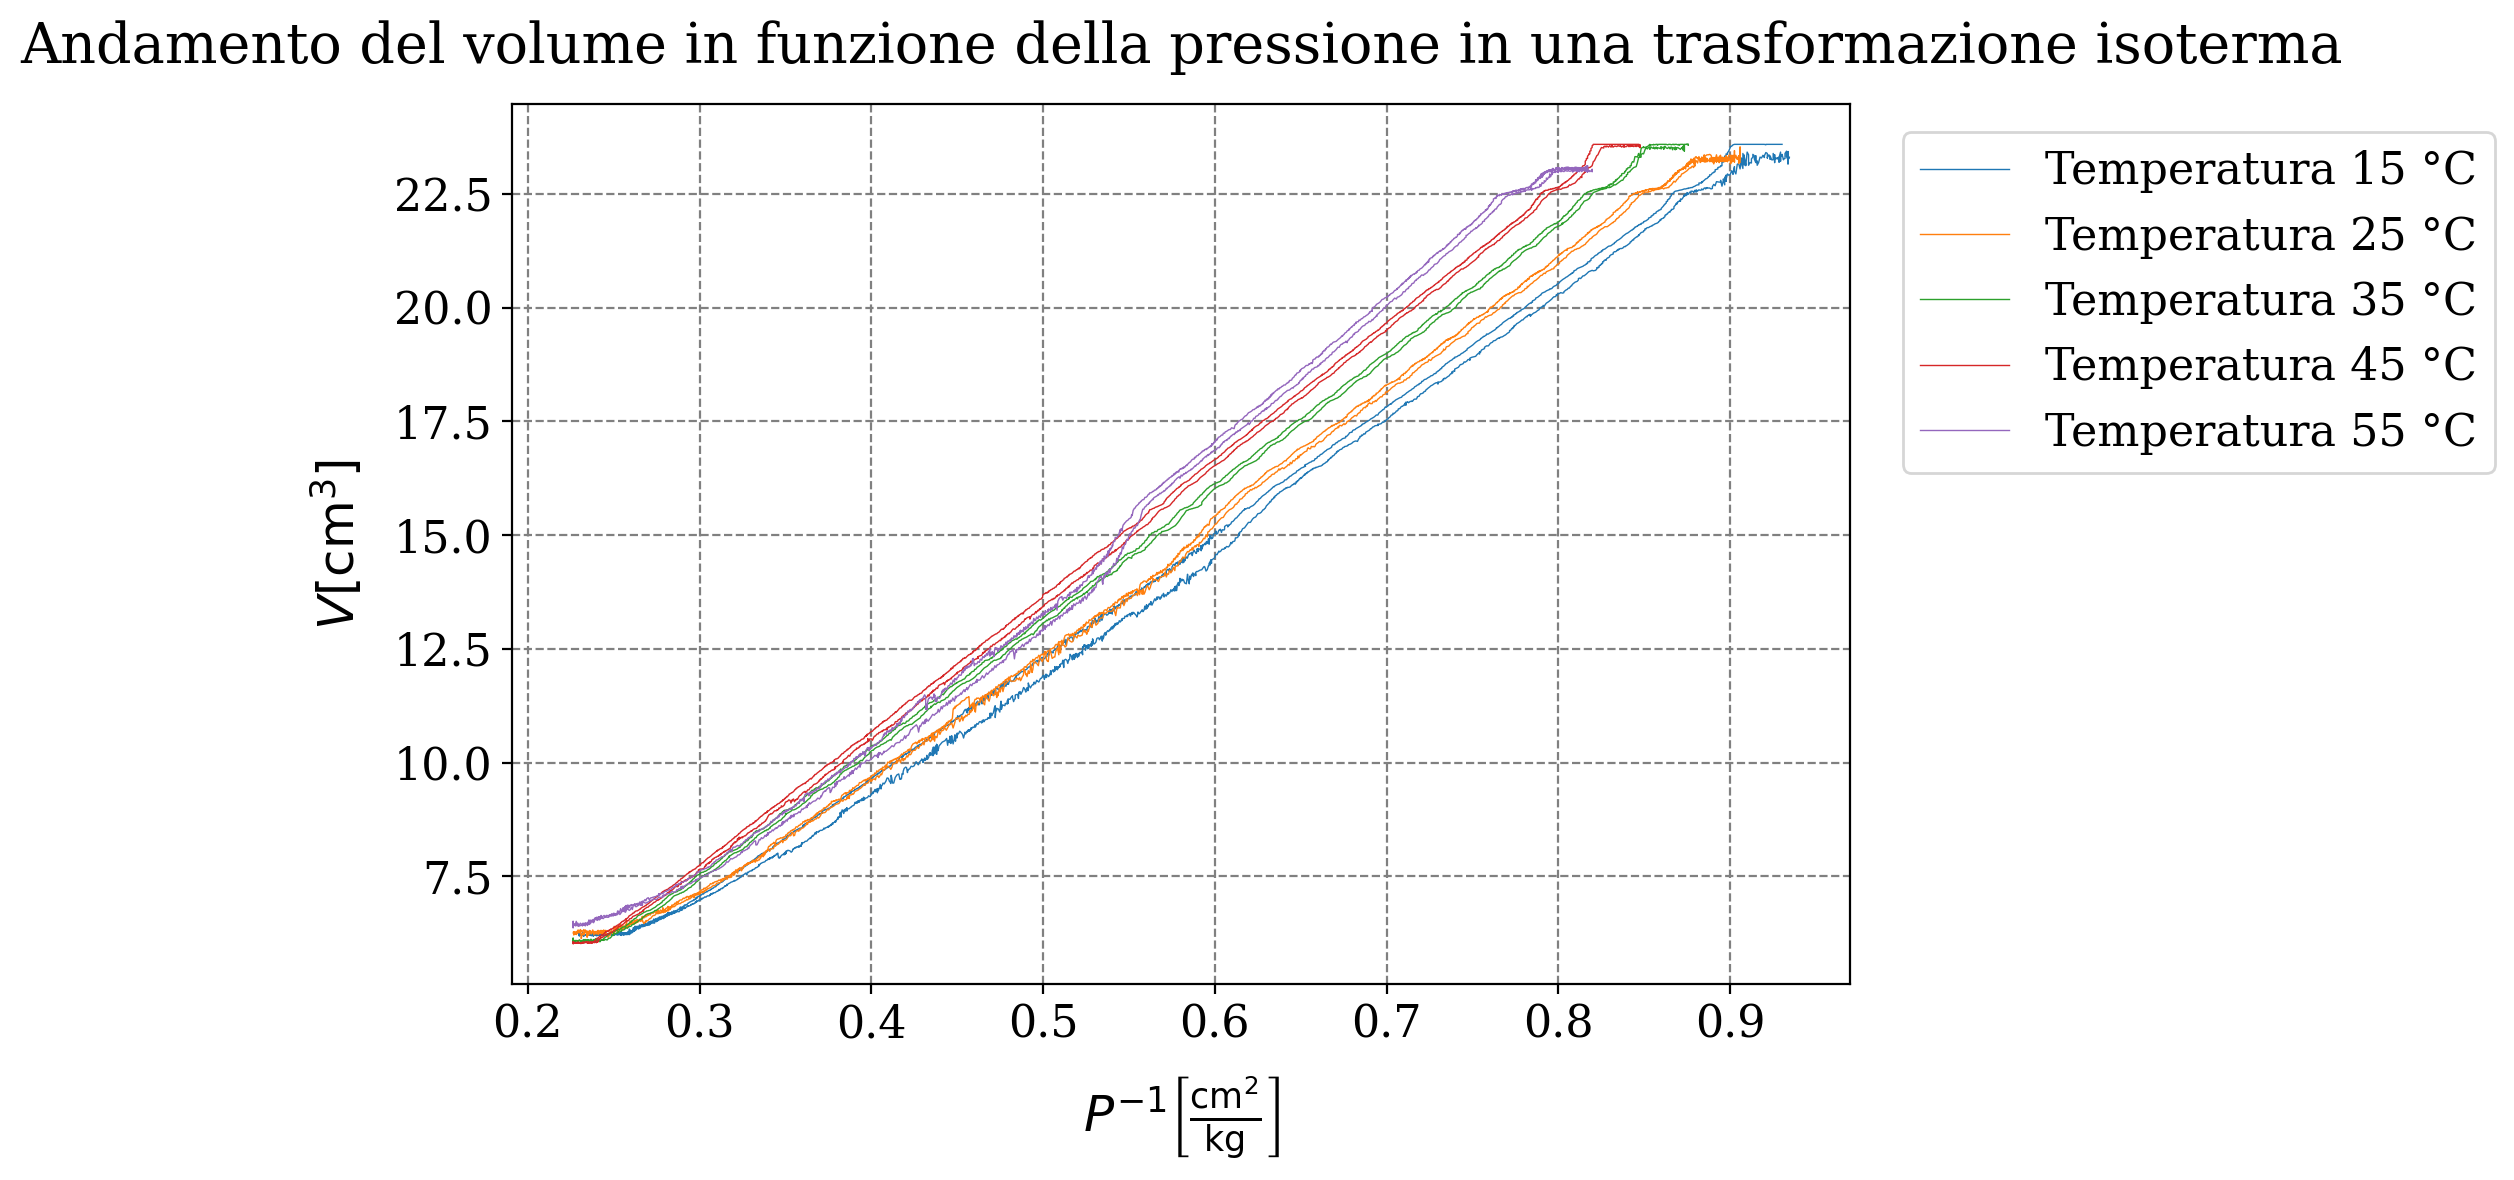

In [12]:
fig, ax = plt.subplots()

for temp, serie in dati_completi.items():
    color = next(color_cycle)
    marker = next(marker_cycle)
    label = f"Temperatura {temp} °C"
    ax.plot(1 / serie["P"], serie["V"], linewidth=0.5, label=label, color=color)

gf.parametri_grafico(ax,
                     titolo = "Andamento del volume in funzione della pressione in una trasformazione isoterma",
                     xlabel = r"$P^{-1} \left[\frac{\mathrm{cm}^2}{\mathrm{kg}}\right]$",
                     ylabel = r"$V [\mathrm{cm^{3}}]$")

gf.salva_grafico(fig, f"./Images/" + directory + "/Confronto.pdf", legenda=(1,0.9))

### 2.1.2 Residui

In [13]:
def grafico_residui(dizionario, directory, color_cycle, marker_cycle, parametri):
    fig, ax = plt.subplots()
    gf.descrizione_legenda(ax,"Temperatura:")

    # Inizializzazione valori x_range
    x_min = 1 / dati["15"]["compressione"]["P"][0]
    x_max = x_min

    for temp,serie in dizionario.items():
        for fase_chiave, fase in serie.items():
            color = next(color_cycle)
            marker = next(marker_cycle)
            label = f"{temp} °C, {fase_chiave}"

            residui=[]
            a = parametri[temp][fase_chiave]["a"]
            b = parametri[temp][fase_chiave]["b"]

            for y,x in zip(fase["V"],fase["P"]):
                residui.append(y - (a + b * 1/x))

                # Calcolo x_range
                if 1/x < x_min: x_min = 1/x
                if 1/x > x_max: x_max = 1/x

            residui = np.array(residui)
            indici = list(range(0, len(residui)))
            gf.descrizione_legenda(ax, label, color=color, marker=marker)
            ax.scatter(1 / fase["P"], residui, marker=marker, s=0.3, linewidth=0.6, color=color)
            gf.parametri_grafico(ax,
                                titolo = "Residui della retta di regressione",
                                xlabel = r"$P^{-1} \left[\frac{\mathrm{cm}^2}{\mathrm{kg}}\right]$",
                                ylabel = r"$Residui [cm^{3}]$")

    gf.linea(ax, np.linspace(x_min,x_max,100), color = "red", salto = estremo)
    gf.linea(ax, np.linspace(x_min,x_max,100), color = "red", salto = -estremo)
    gf.salva_grafico(fig, f"./Images/" + directory + "/Residui.pdf", legenda=(1,0.9))

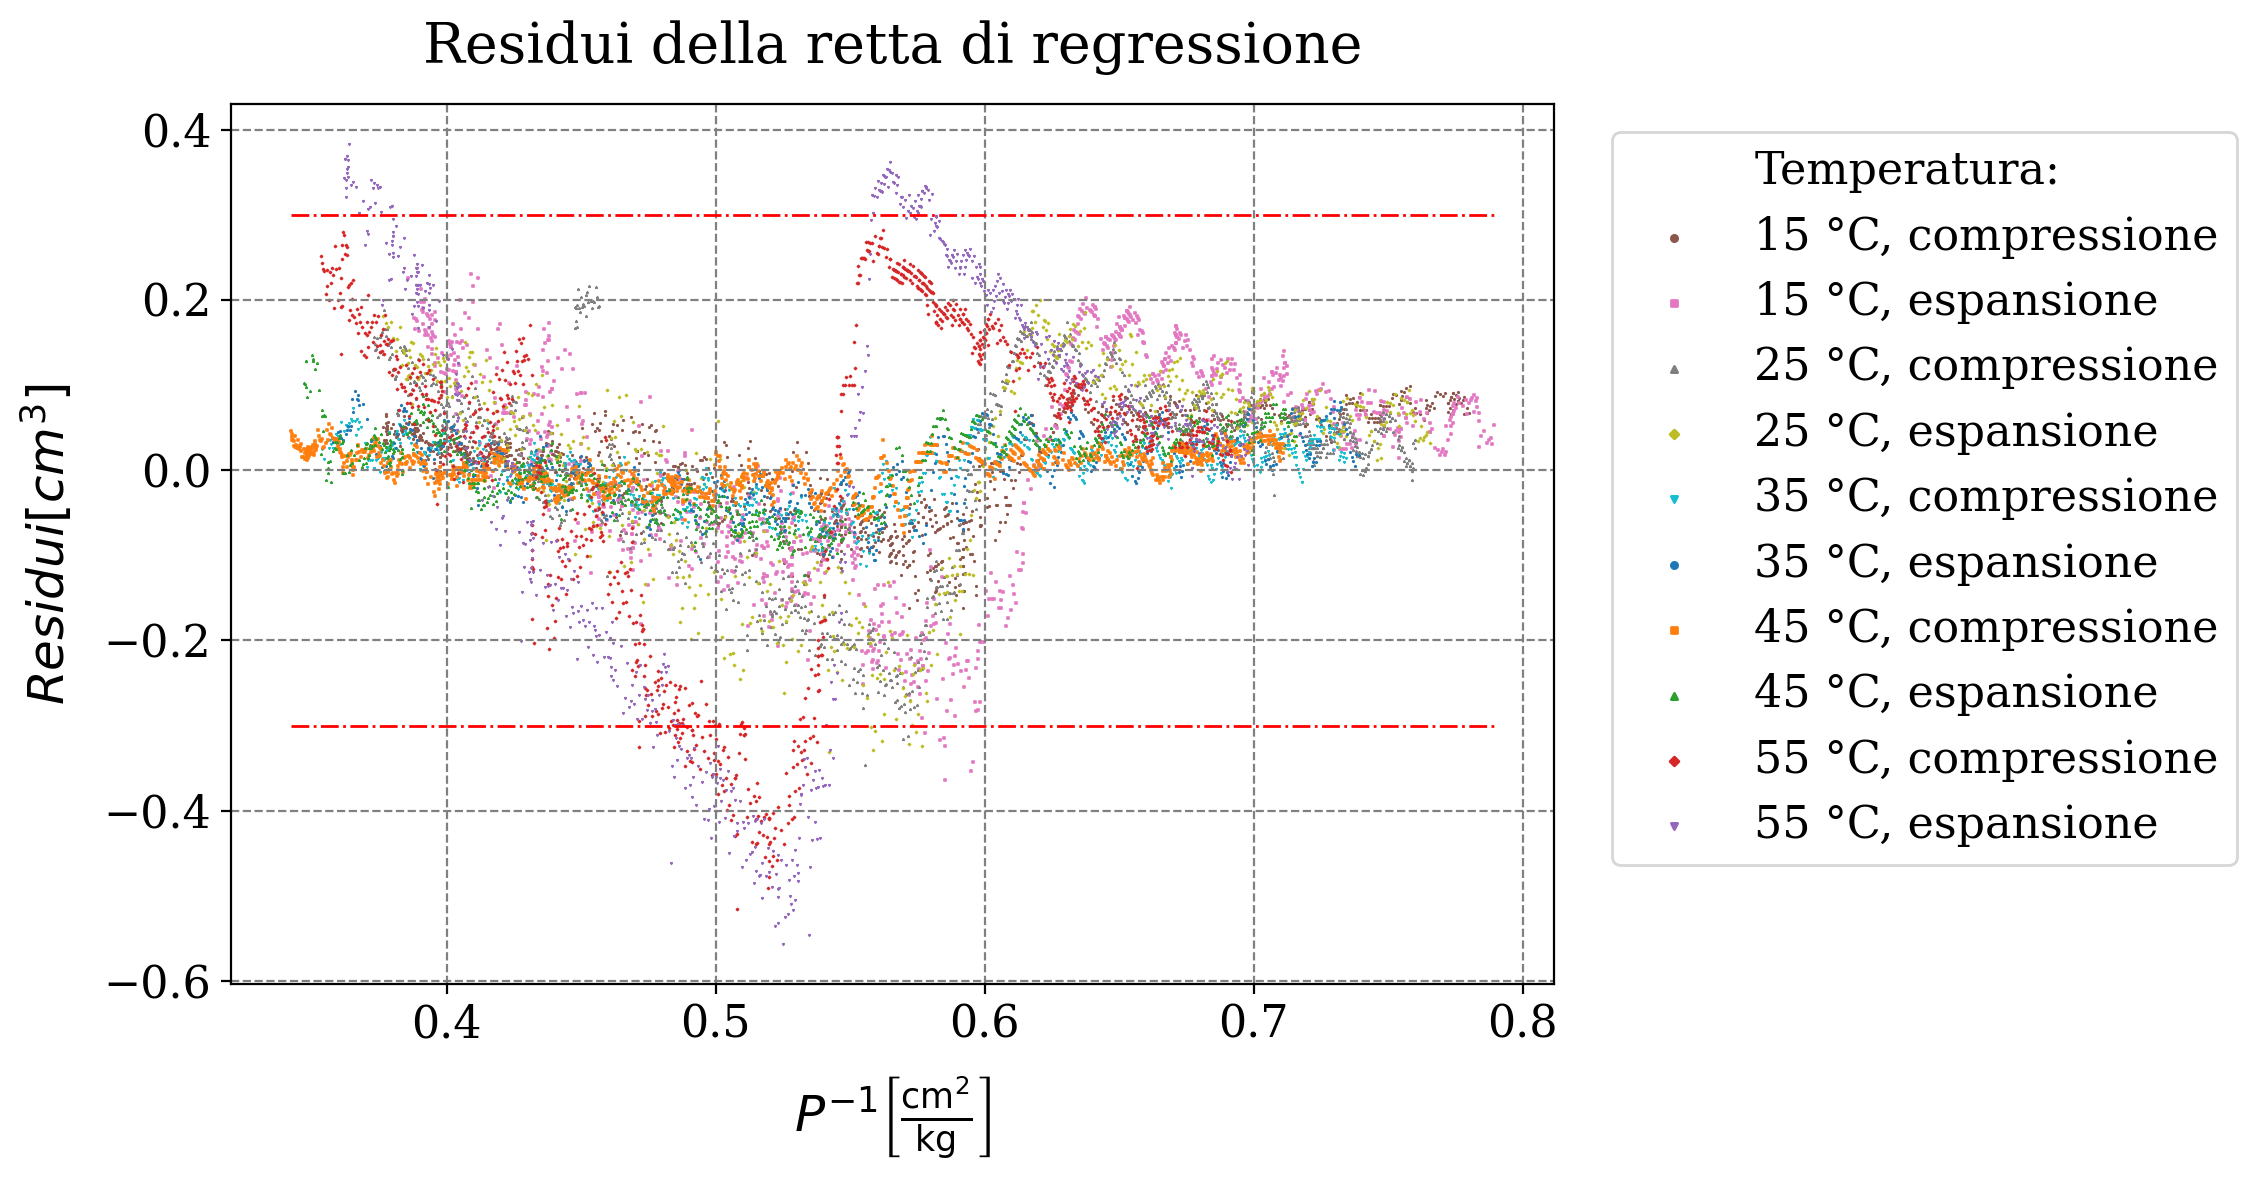

In [14]:
grafico_residui(dati, directory, color_cycle, marker_cycle, parametri)

### 2.1.3 Serie

In [15]:
def grafico_serie(dizionario, directory, color_cycle, marker_cycle, parametri):
    for temp,serie in dizionario.items():
        for fase_chiave, fase in serie.items():
            color = next(color_cycle)
            marker = next(marker_cycle)
            label = [f"{temp} °C, {fase_chiave}" ,
                    f"a: {parametri[temp][fase_chiave]['a']:.2f} ± {parametri[temp][fase_chiave]['sa']:.2f}",
                    f"b: {parametri[temp][fase_chiave]['b']:.2f} ± {parametri[temp][fase_chiave]['sb']:.2f}",
                    f"p: {parametri[temp][fase_chiave]['p']:.2f}",
                    f"errpost: {parametri[temp][fase_chiave]['errpost']:.3f}"]

            fig, axs = plt.subplots(2, 1, figsize=(10, 8))
            ax1 = axs[0]
            ax2 = axs[1]

            residui=[]
            a = parametri[temp][fase_chiave]["a"]
            b = parametri[temp][fase_chiave]["b"]

            for y,x in zip(fase["V"],fase["P"]):
                residui.append(y - (a + b * 1/x))
            residui = np.array(residui)
            indici = list(range(0, len(residui)))

            # Legenda
            for i,sotto_legenda in enumerate(label):
                if i == 0:
                    gf.descrizione_legenda(ax1, sotto_legenda, color=color, marker=marker, show=True)
                else:
                    gf.descrizione_legenda(ax1, sotto_legenda, show=True)

            # Confronto
            ax1.plot(1 / fase["P"], fase["V"], linewidth=0.5, color=color)
            gf.parametri_grafico(ax1,
                                titolo = "Andamento del volume",
                                xlabel = r"$P^{-1} \left[\frac{\mathrm{cm}^2}{\mathrm{kg}}\right]$",
                                ylabel = r"$V [\mathrm{cm^{3}}]$")

            # Residui pressione
            ax2.scatter(1 / fase["P"], residui, marker=marker, s=0.3, linewidth=0.6, color=color)
            gf.parametri_grafico(ax2,
                                titolo = "Residui della retta di regressione",
                                xlabel = r"$P^{-1} \left[\frac{\mathrm{cm}^2}{\mathrm{kg}}\right]$",
                                ylabel = r"$Residui [cm^{3}]$")
            """
            # Residui conteggi
            ax3.scatter(indici, residui, marker=marker, s=0.3, linewidth=0.6, color=color)
            gf.parametri_grafico(ax3,
                                titolo = "Residui della retta di regressione",
                                xlabel = "Conteggi",
                                ylabel = r"$Residui [cm^{3}]$")
            """

            # Salva i grafici
            gf.salva_grafico(fig, f"./Images/" + directory + "/Serie_{temp}_{fase_chiave}.pdf", noLegenda=True)

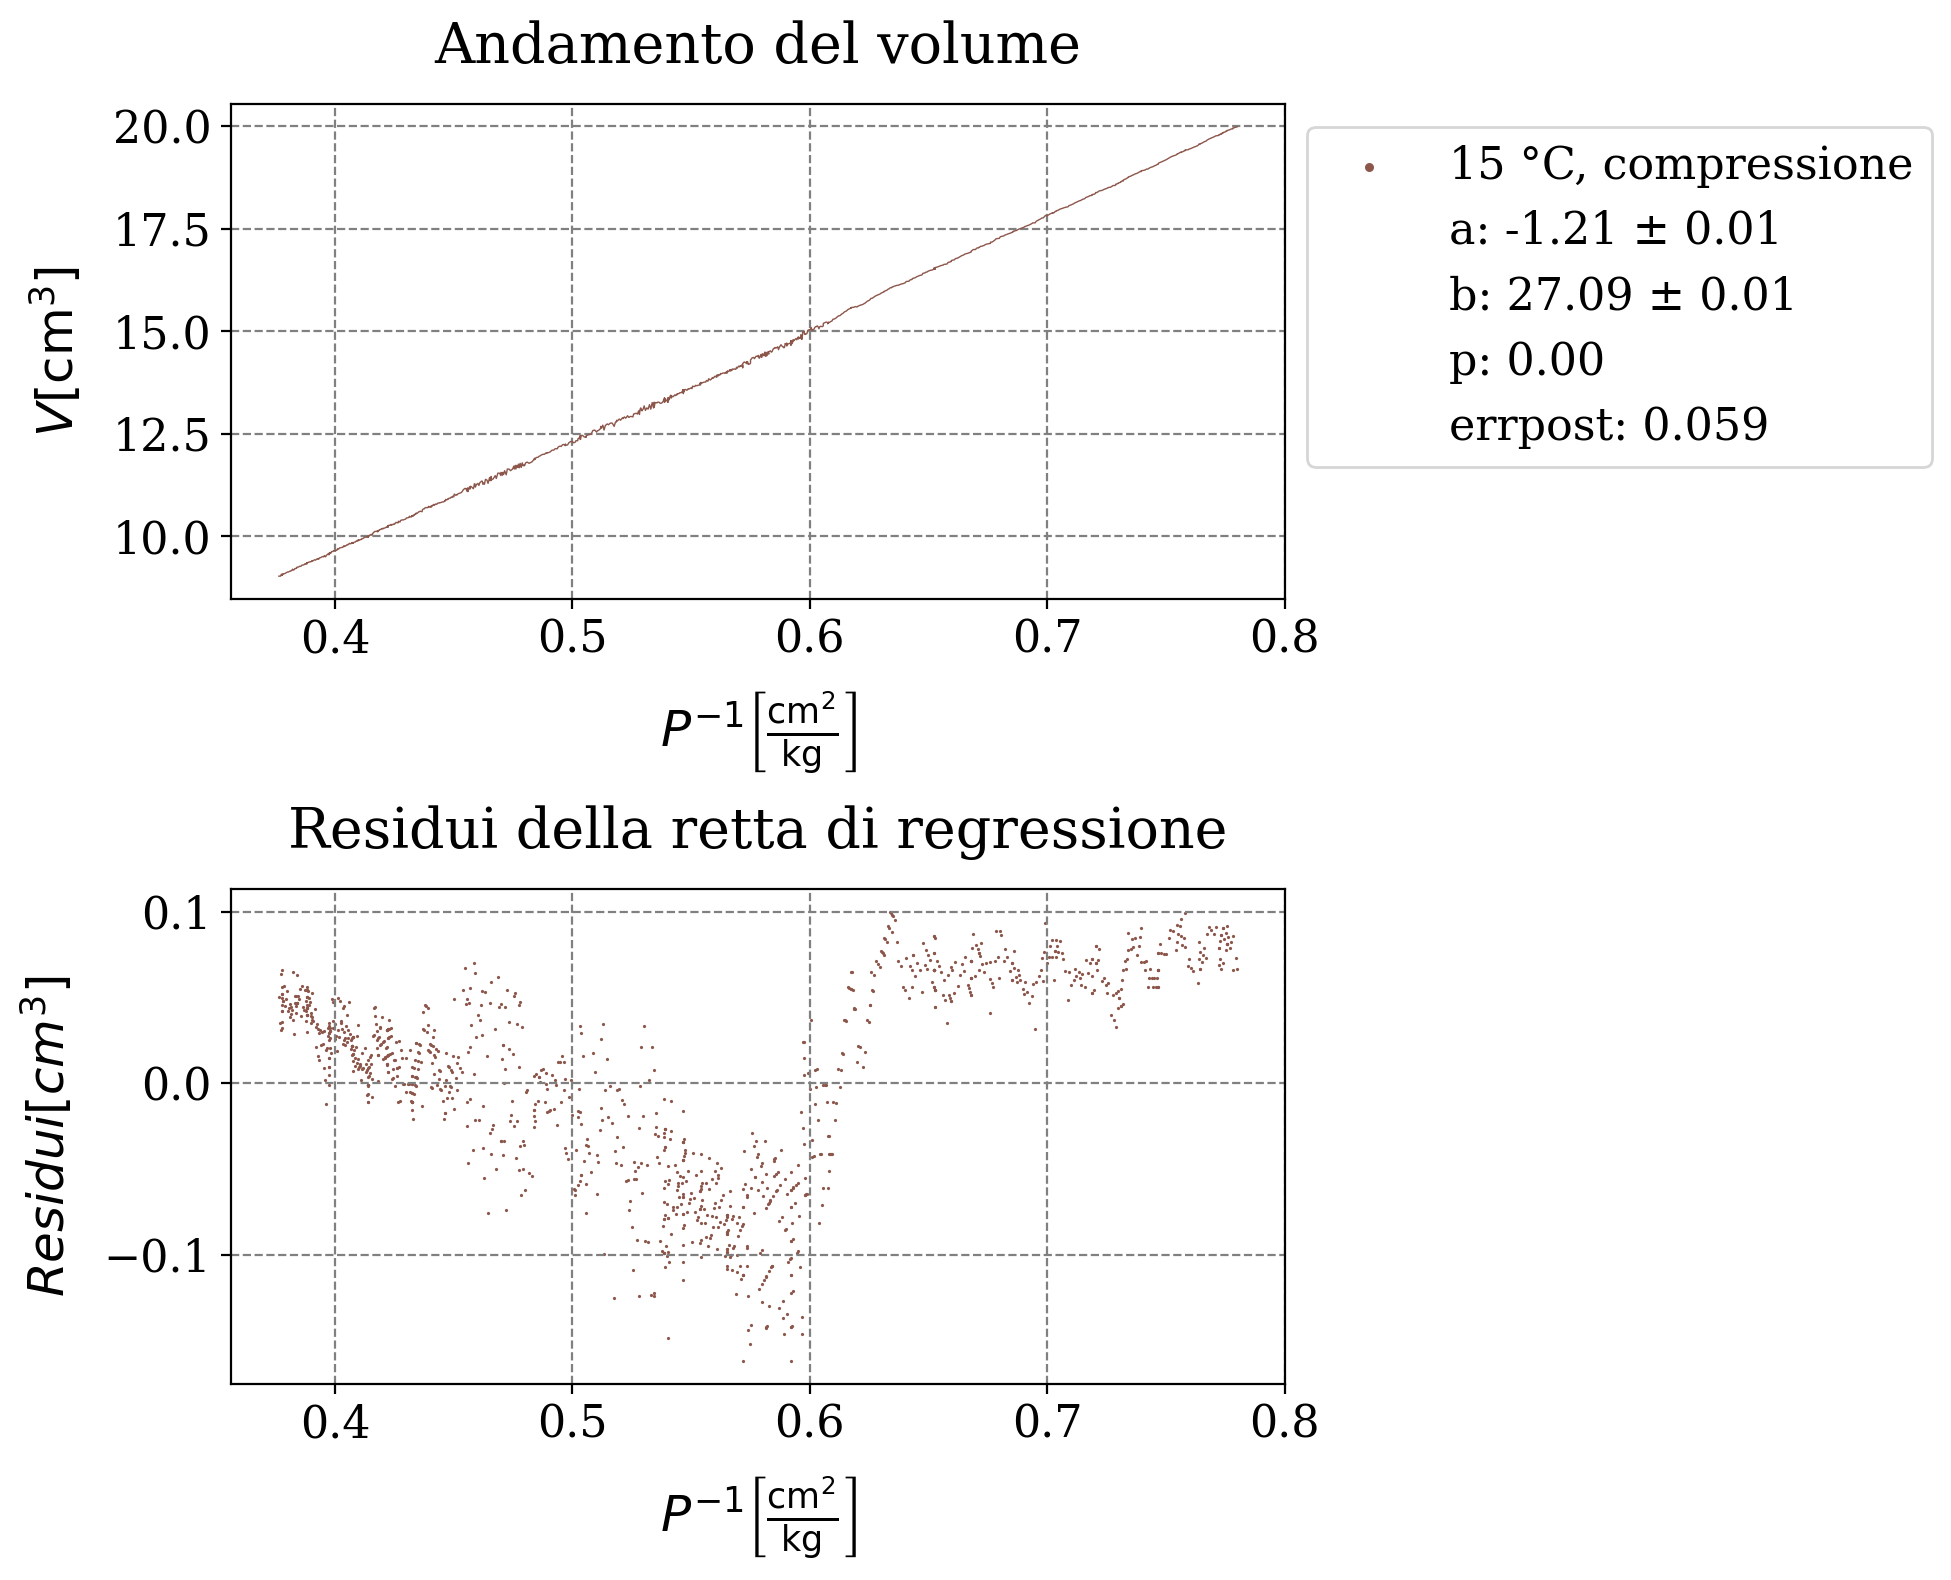

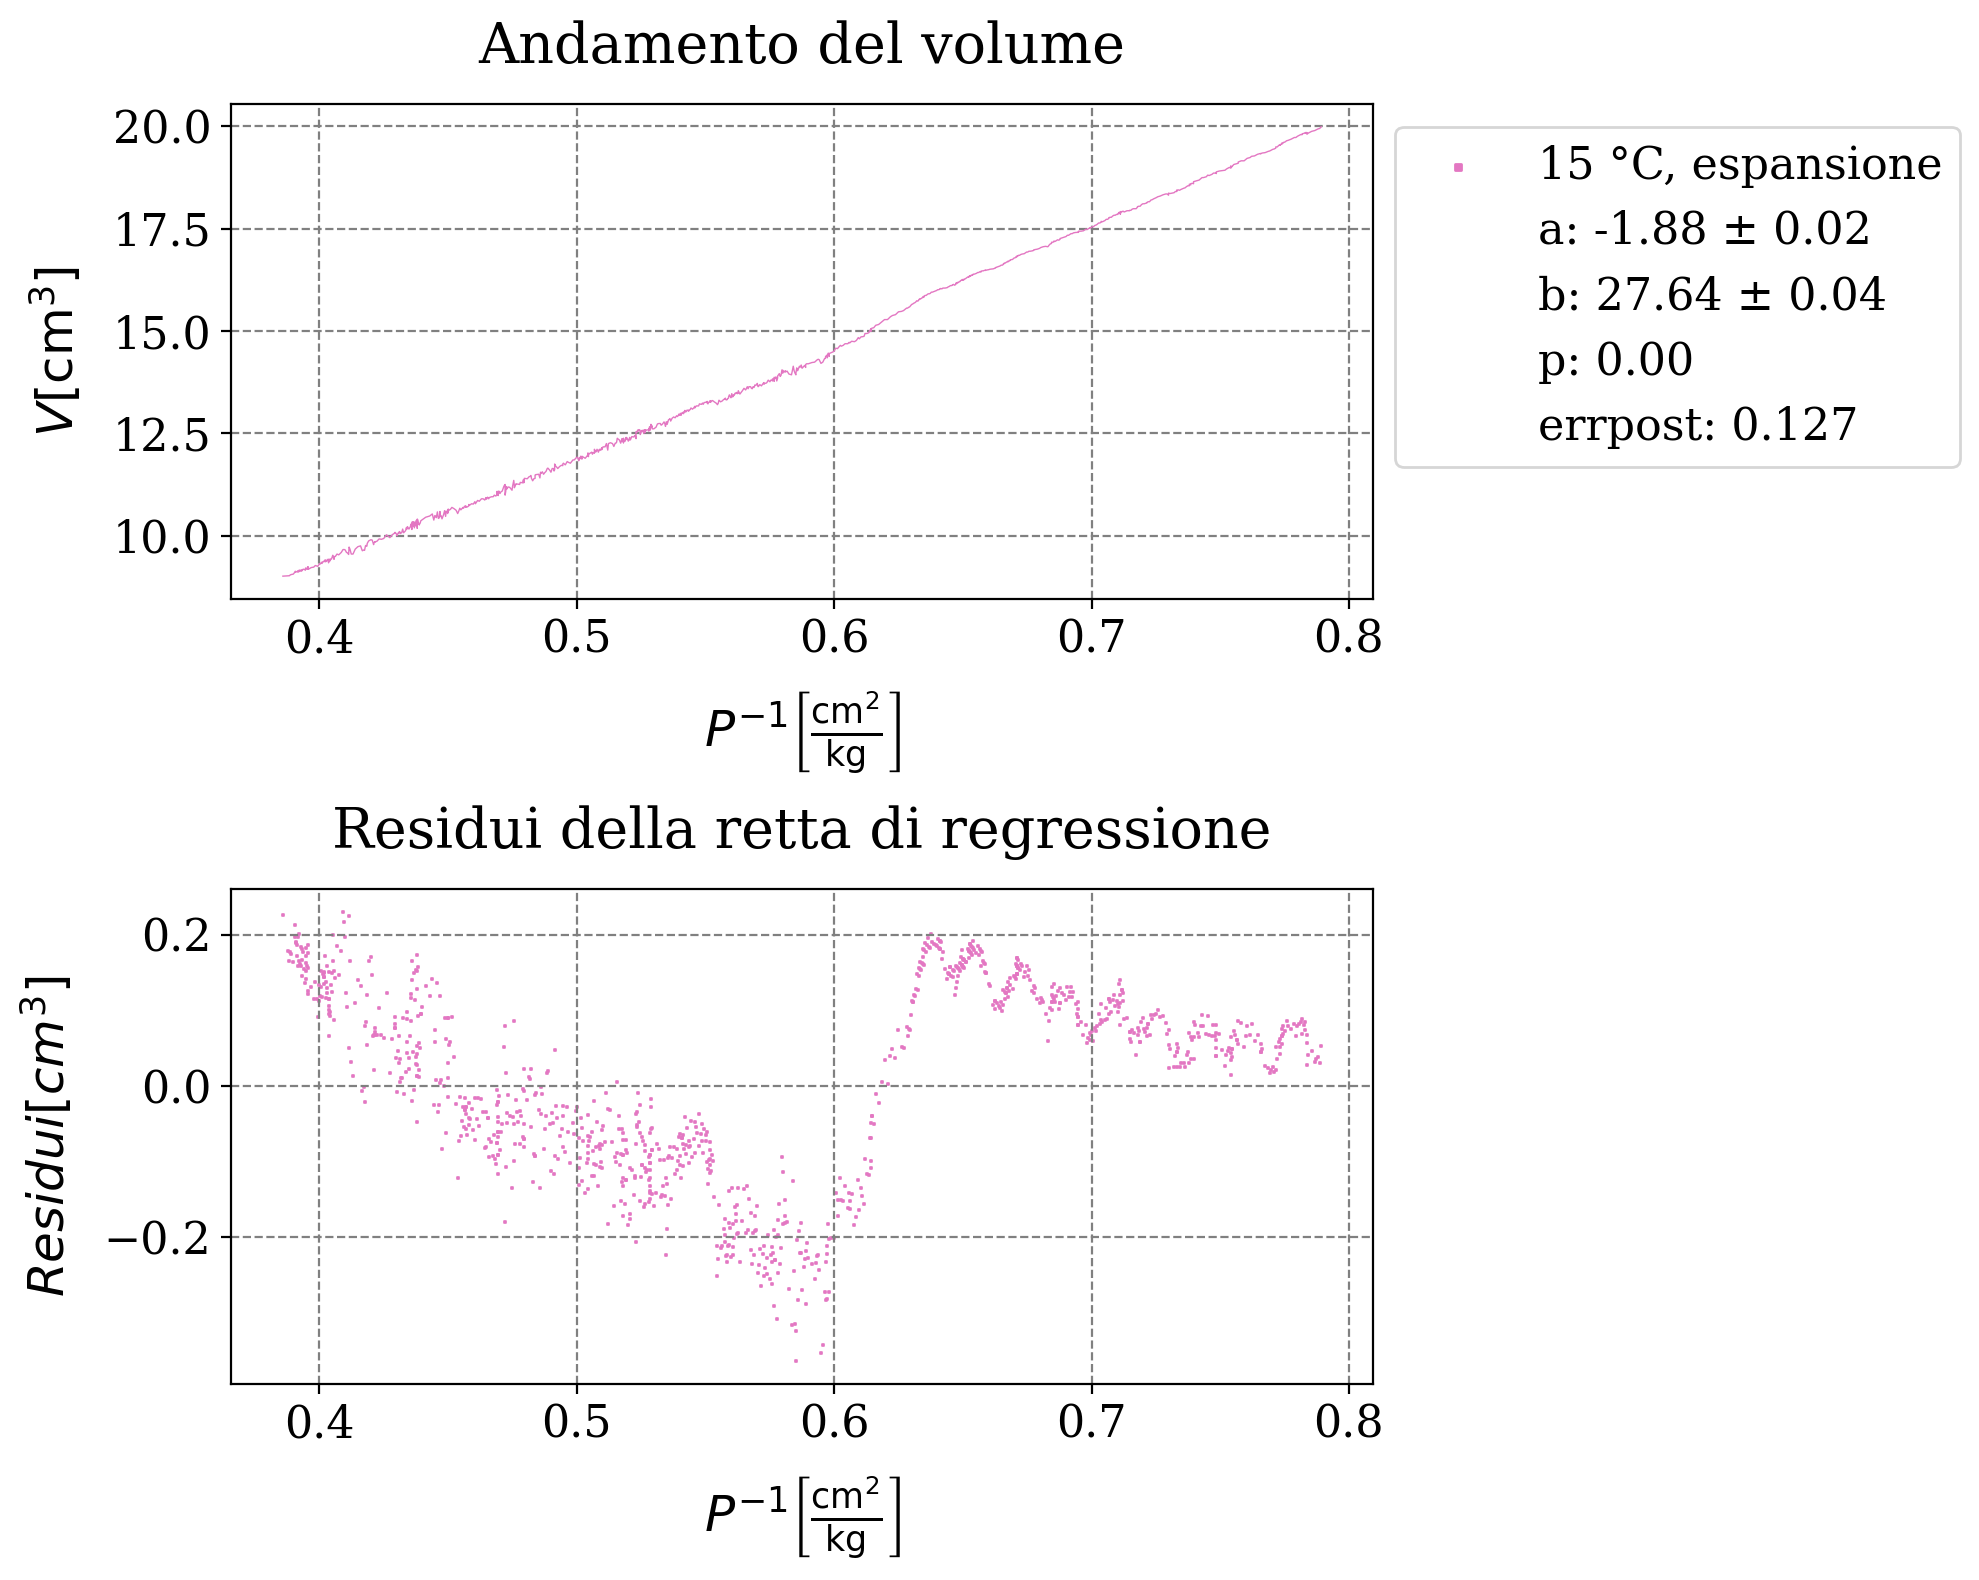

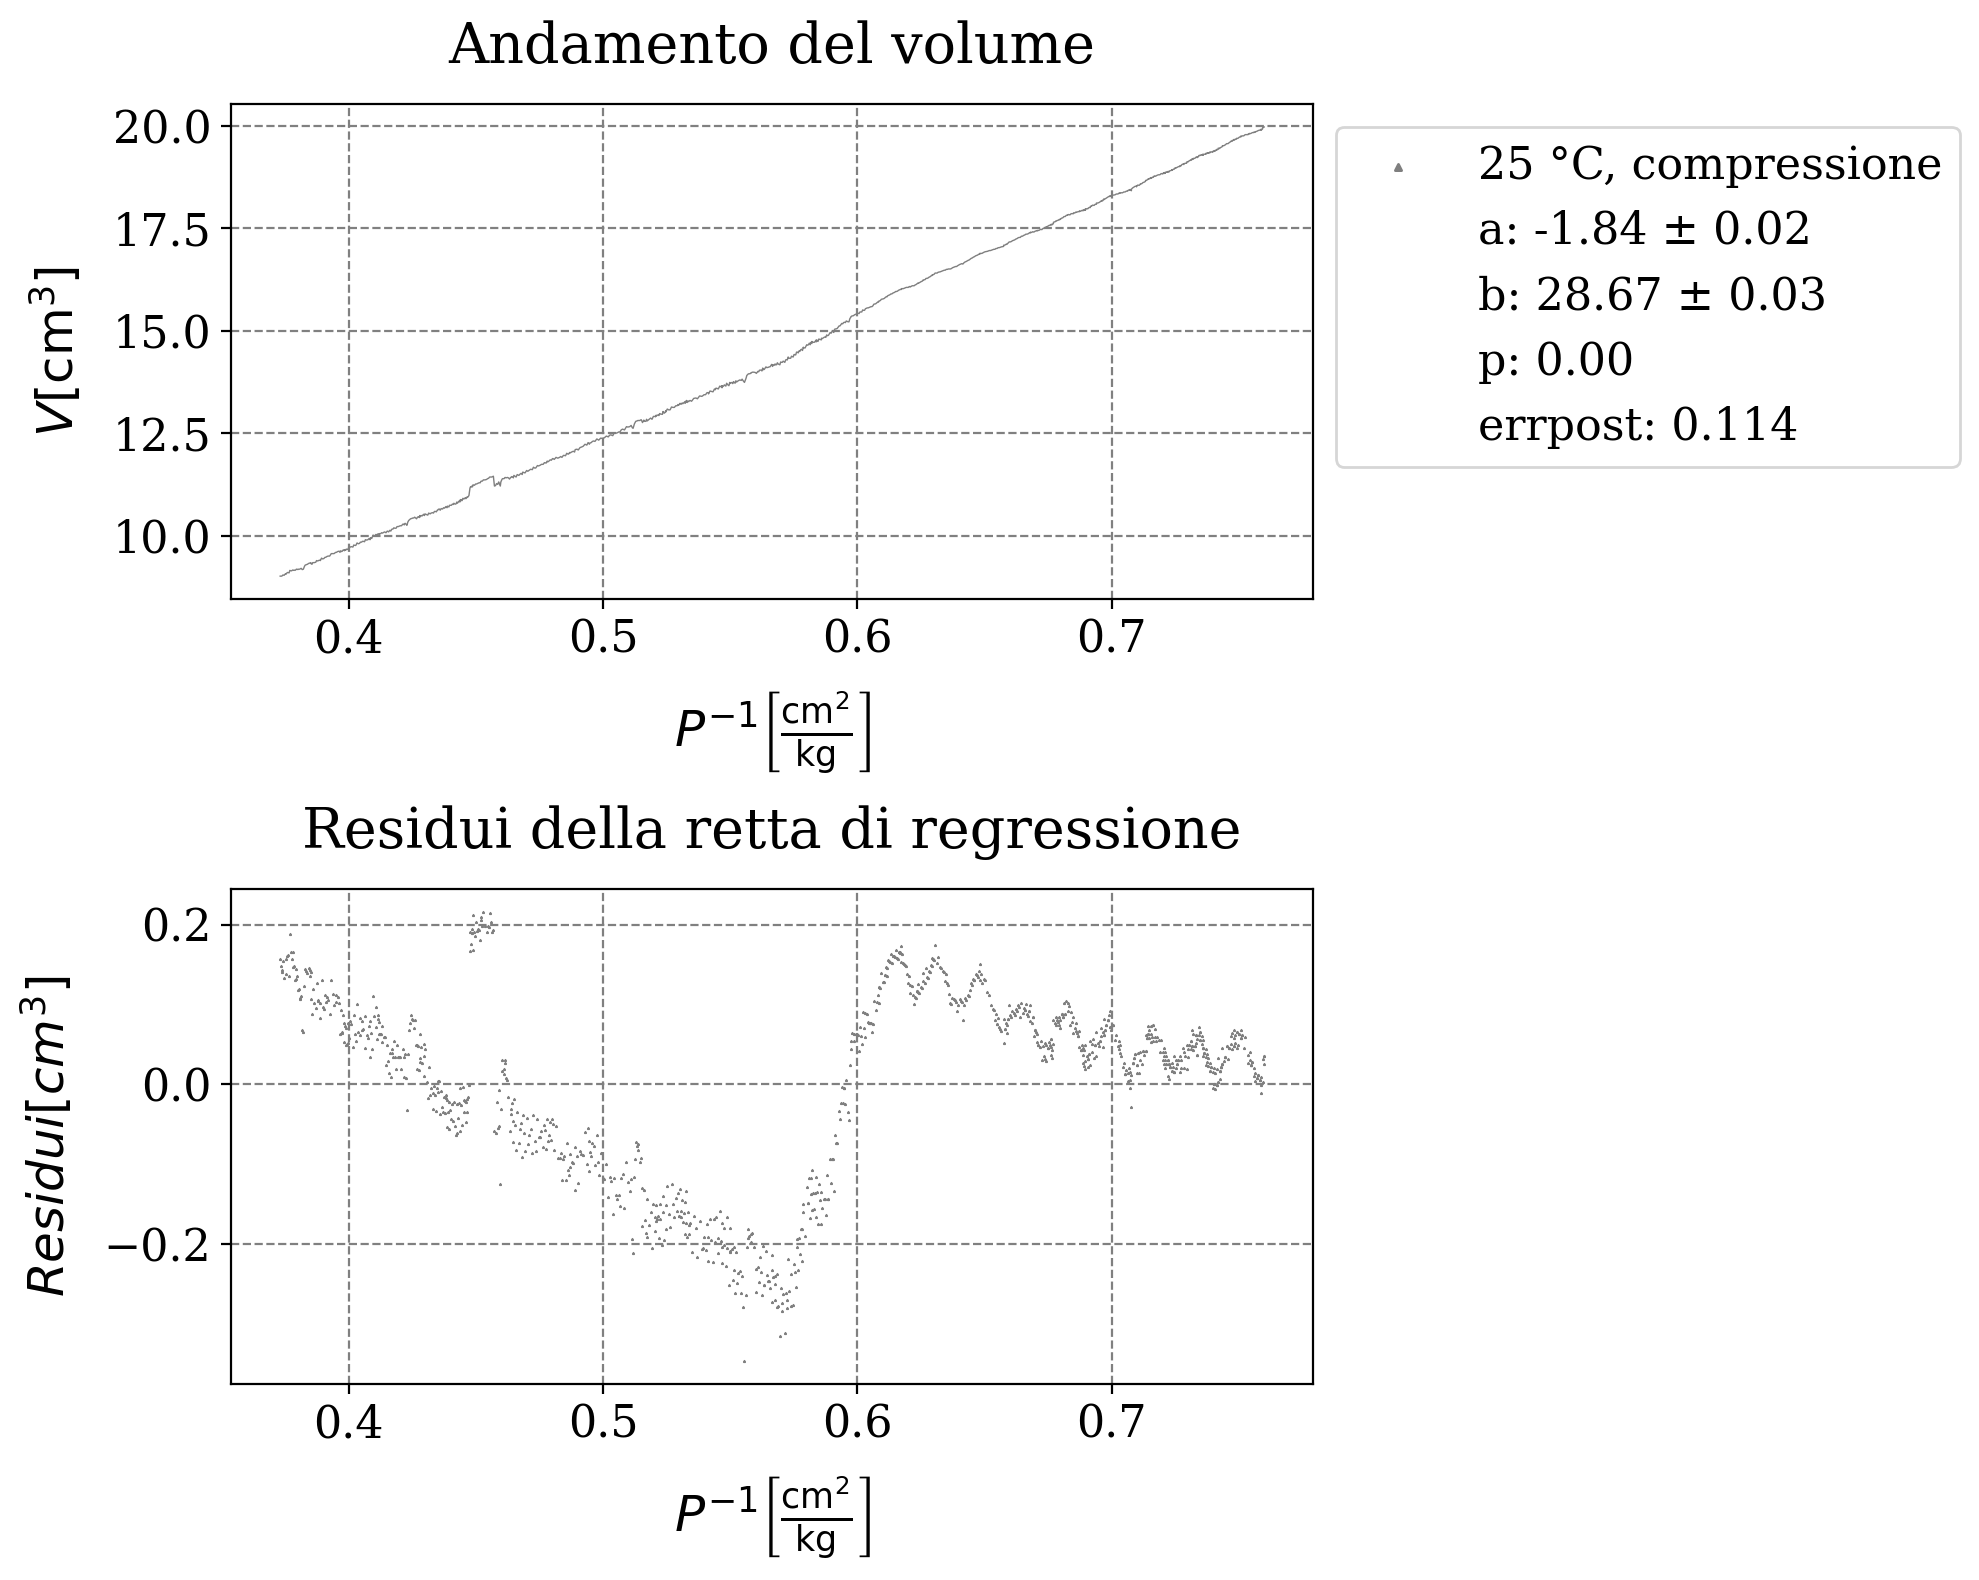

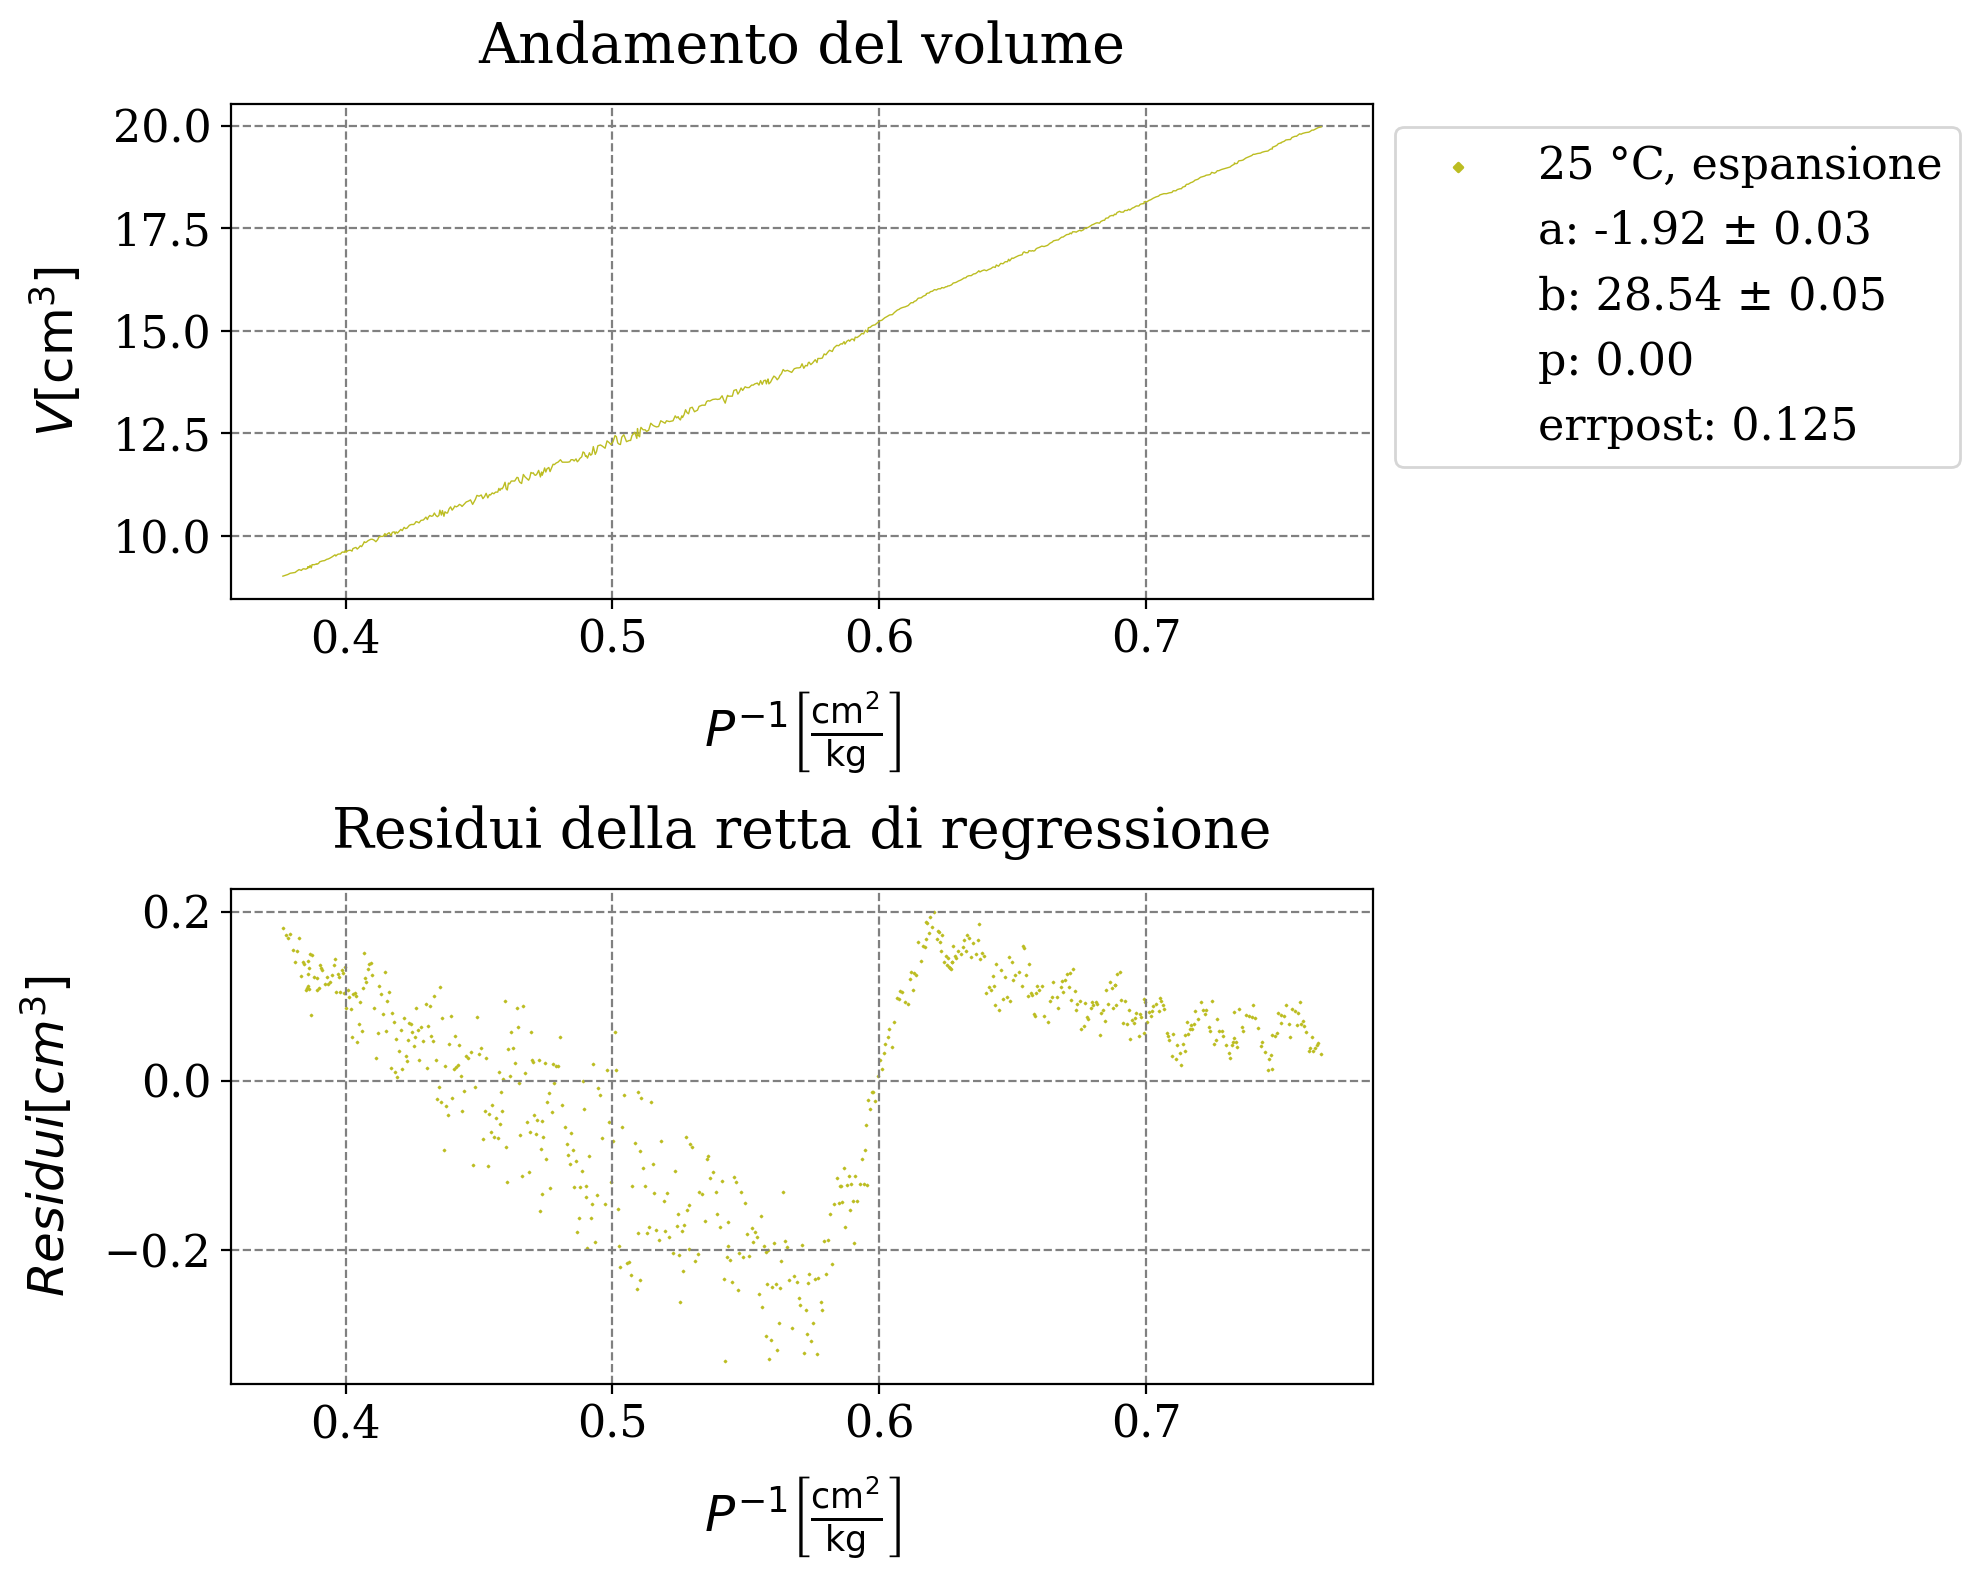

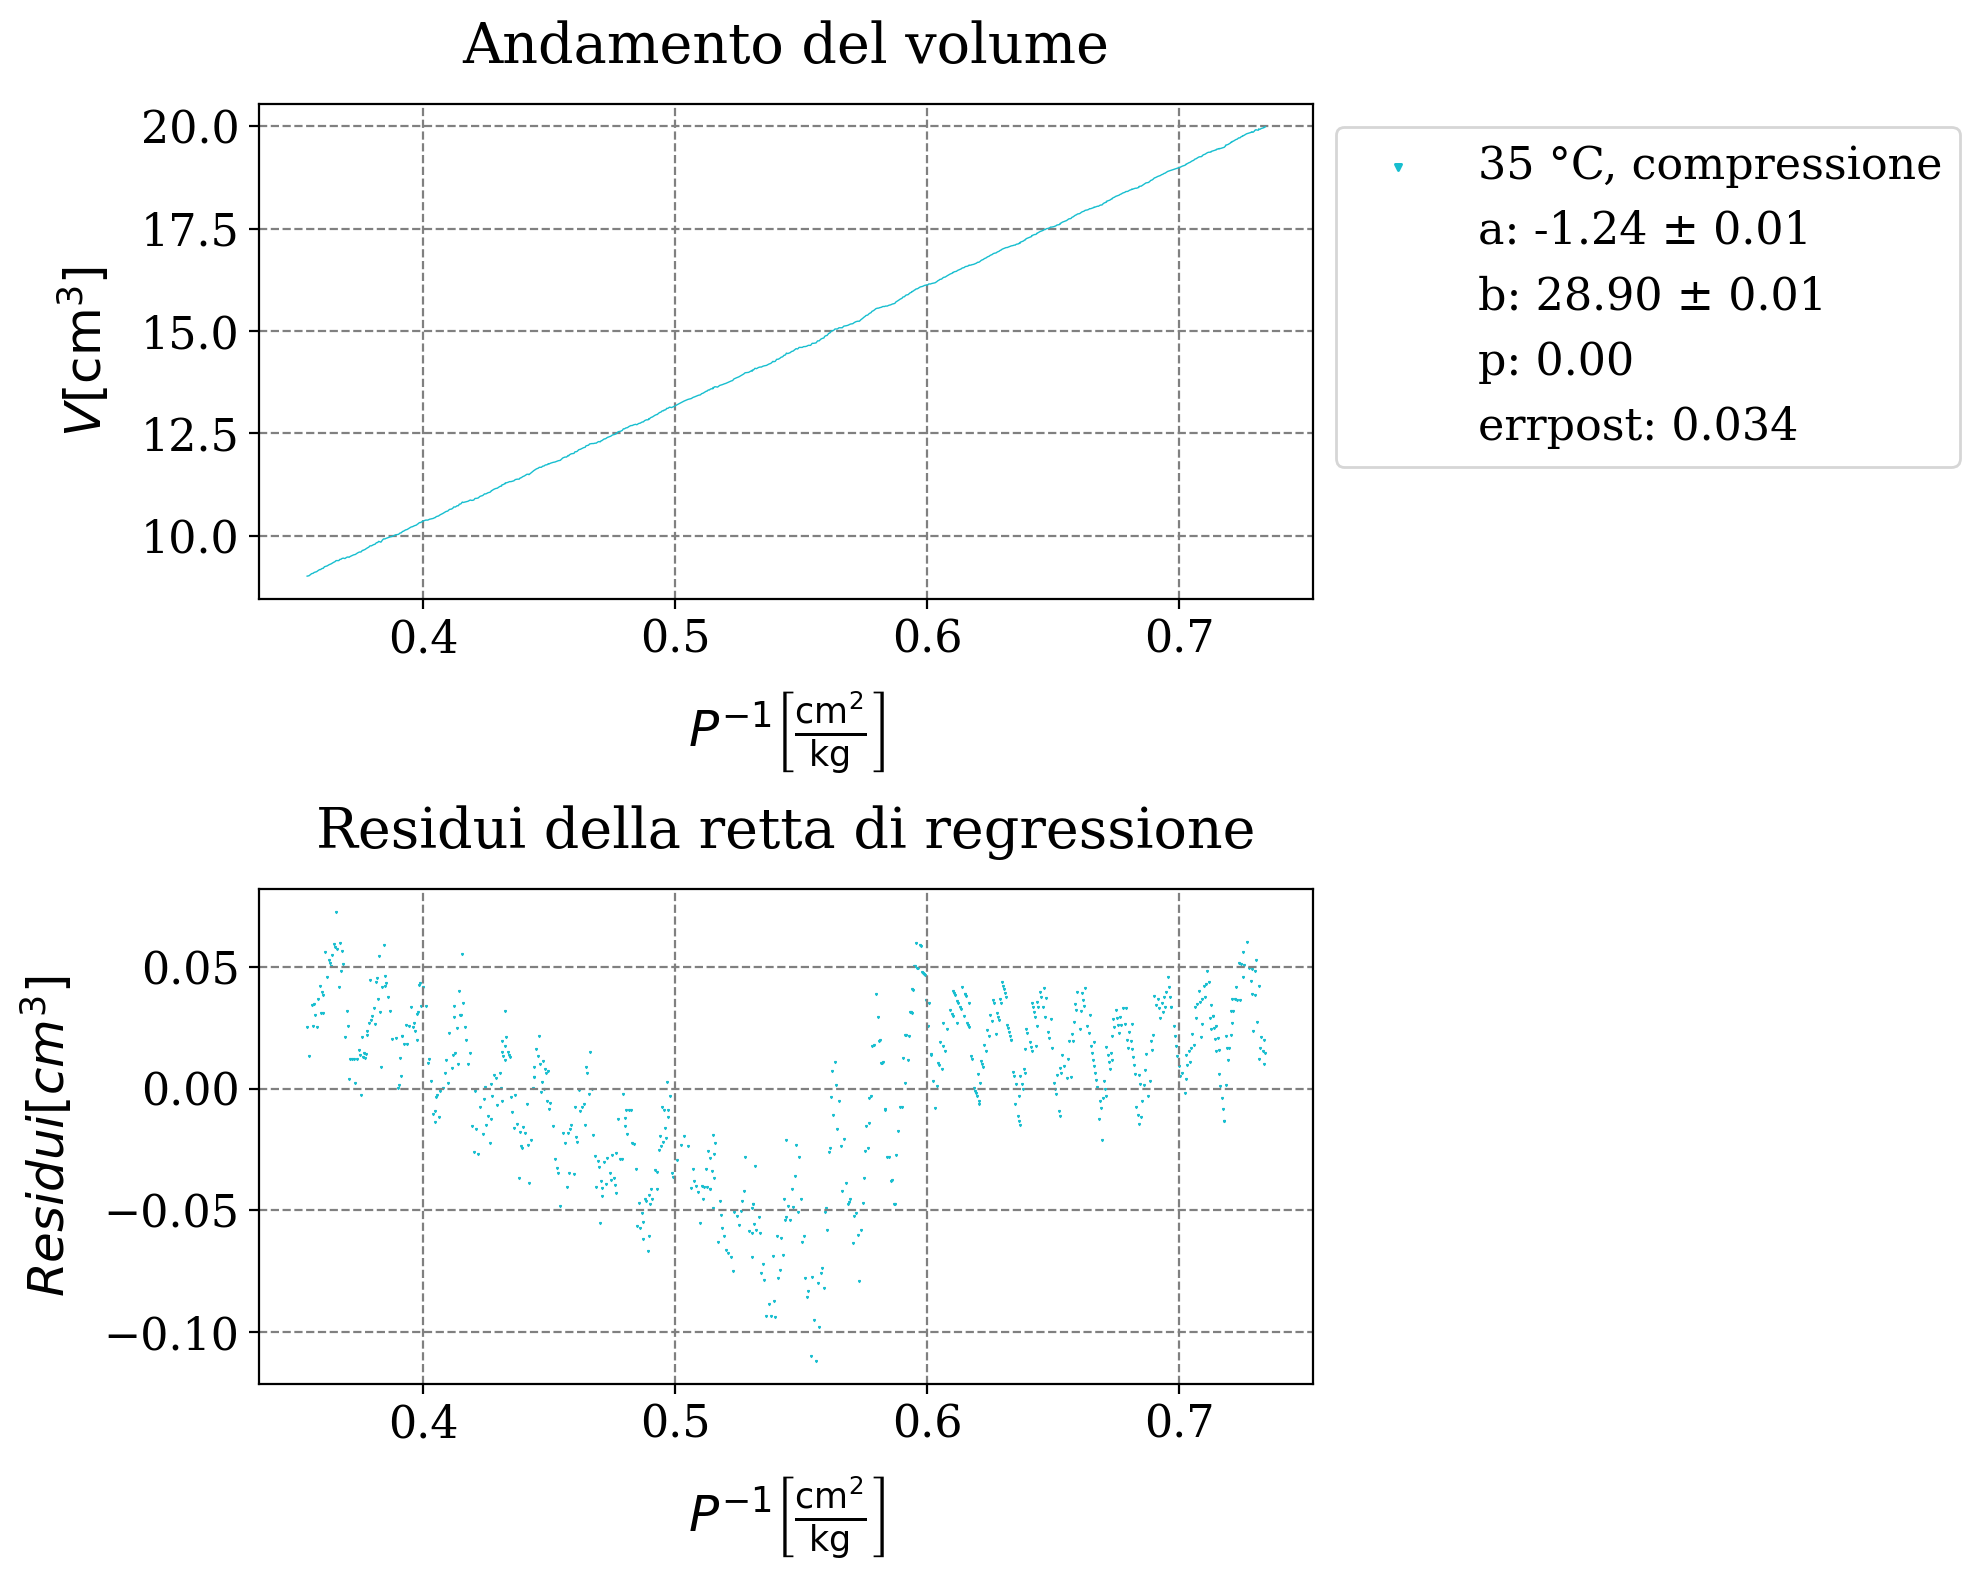

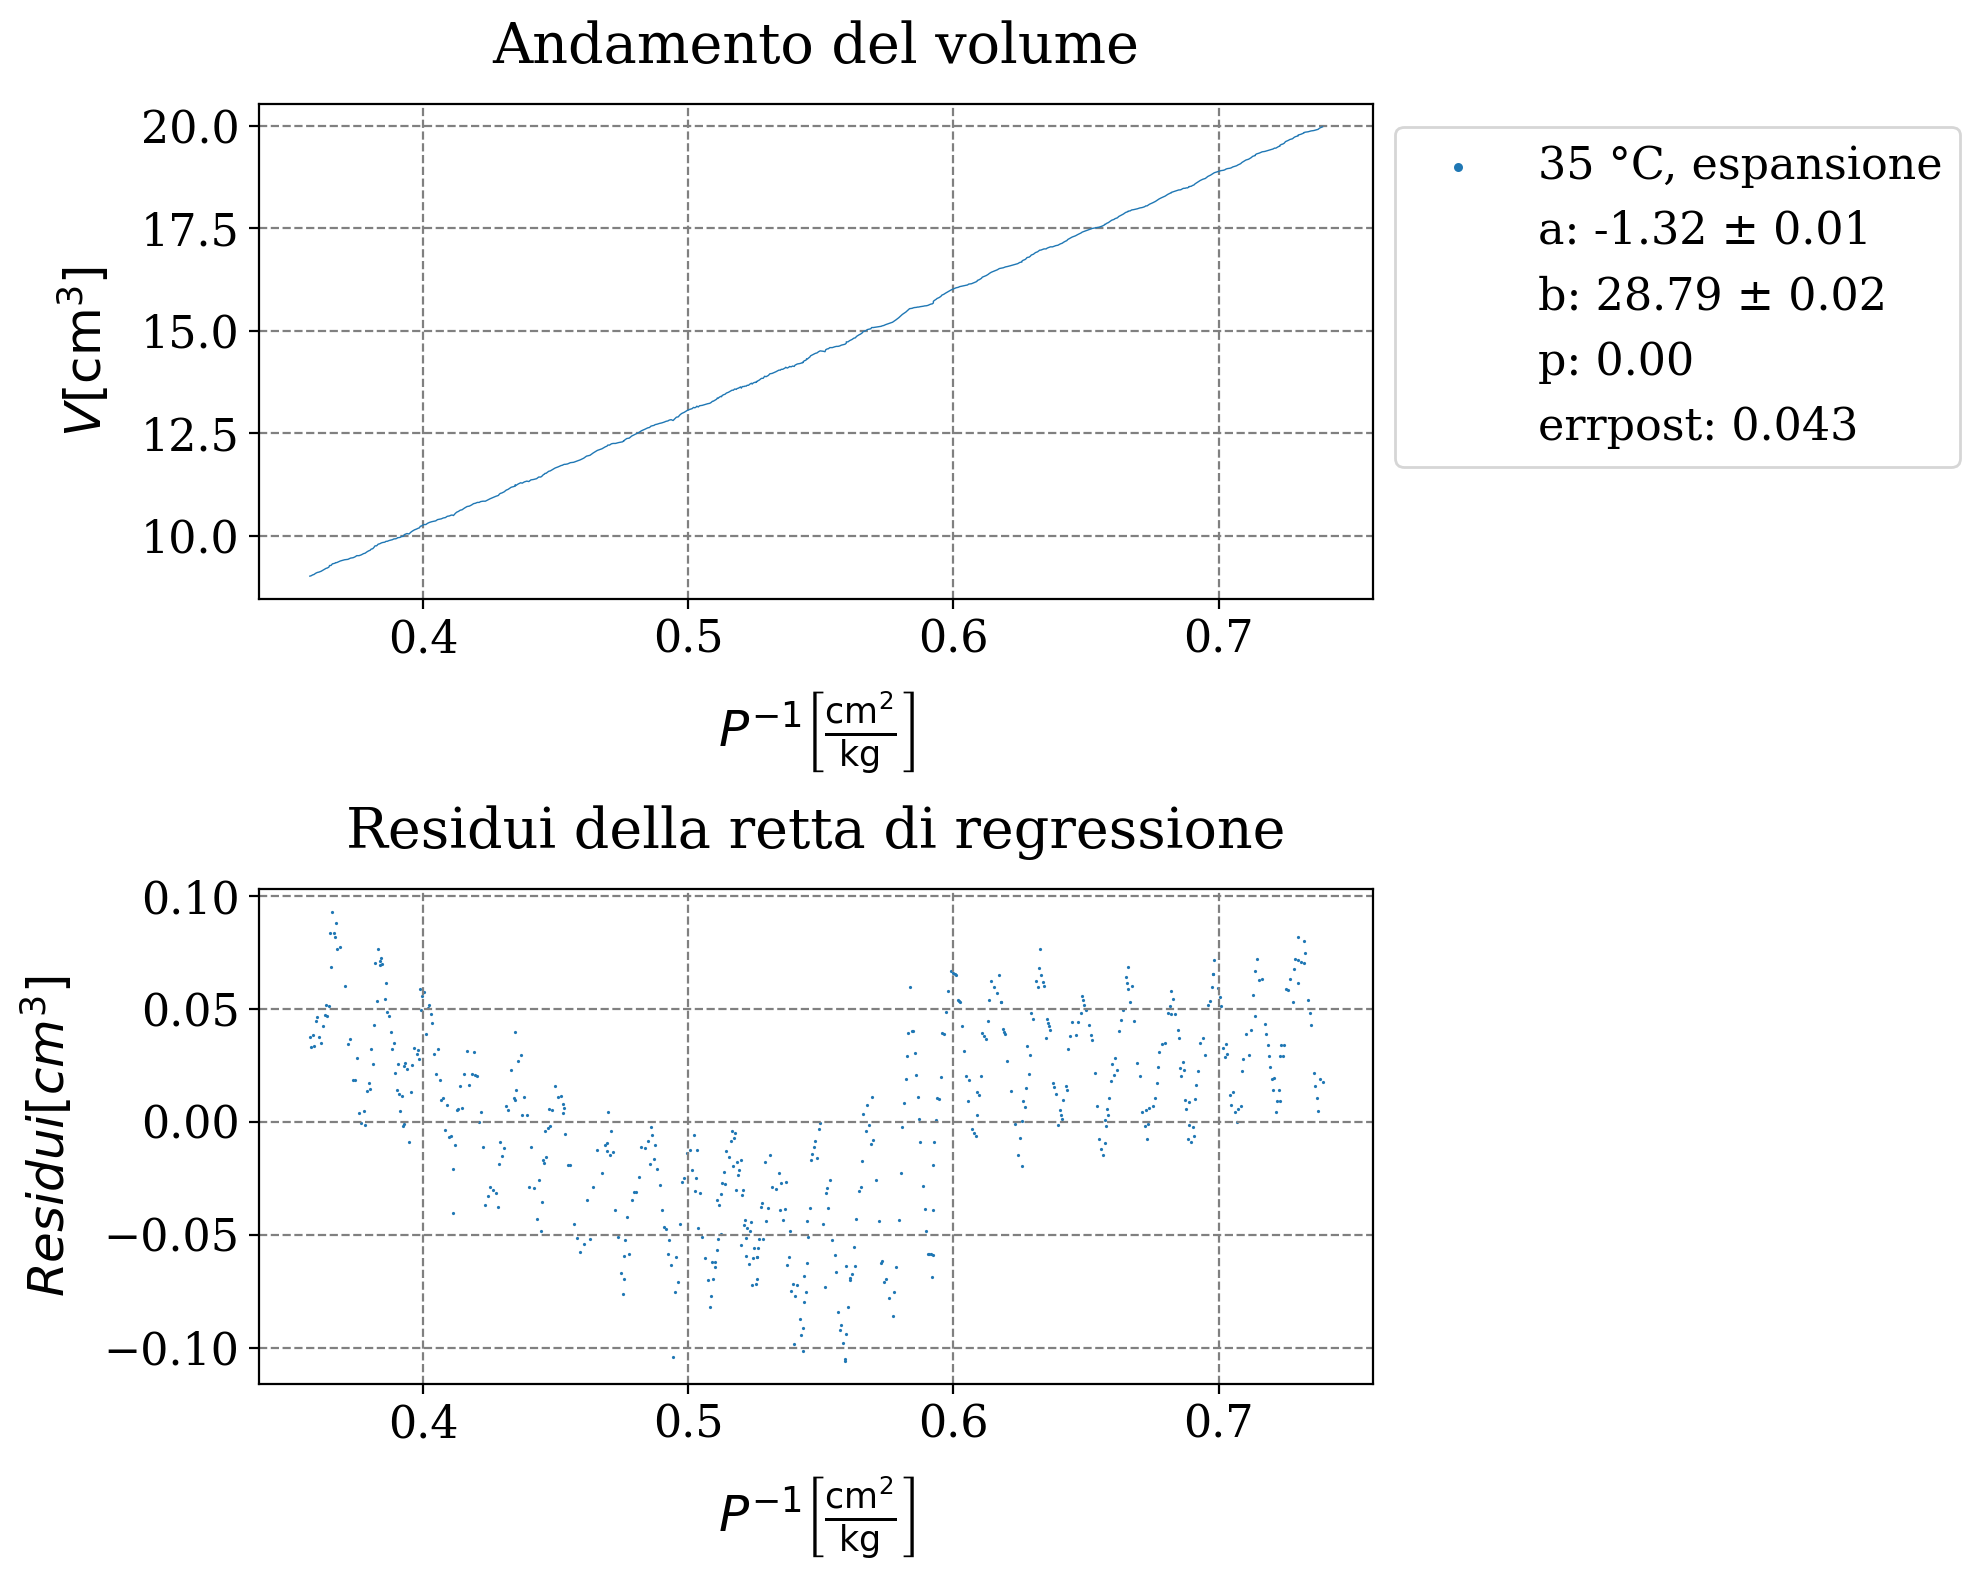

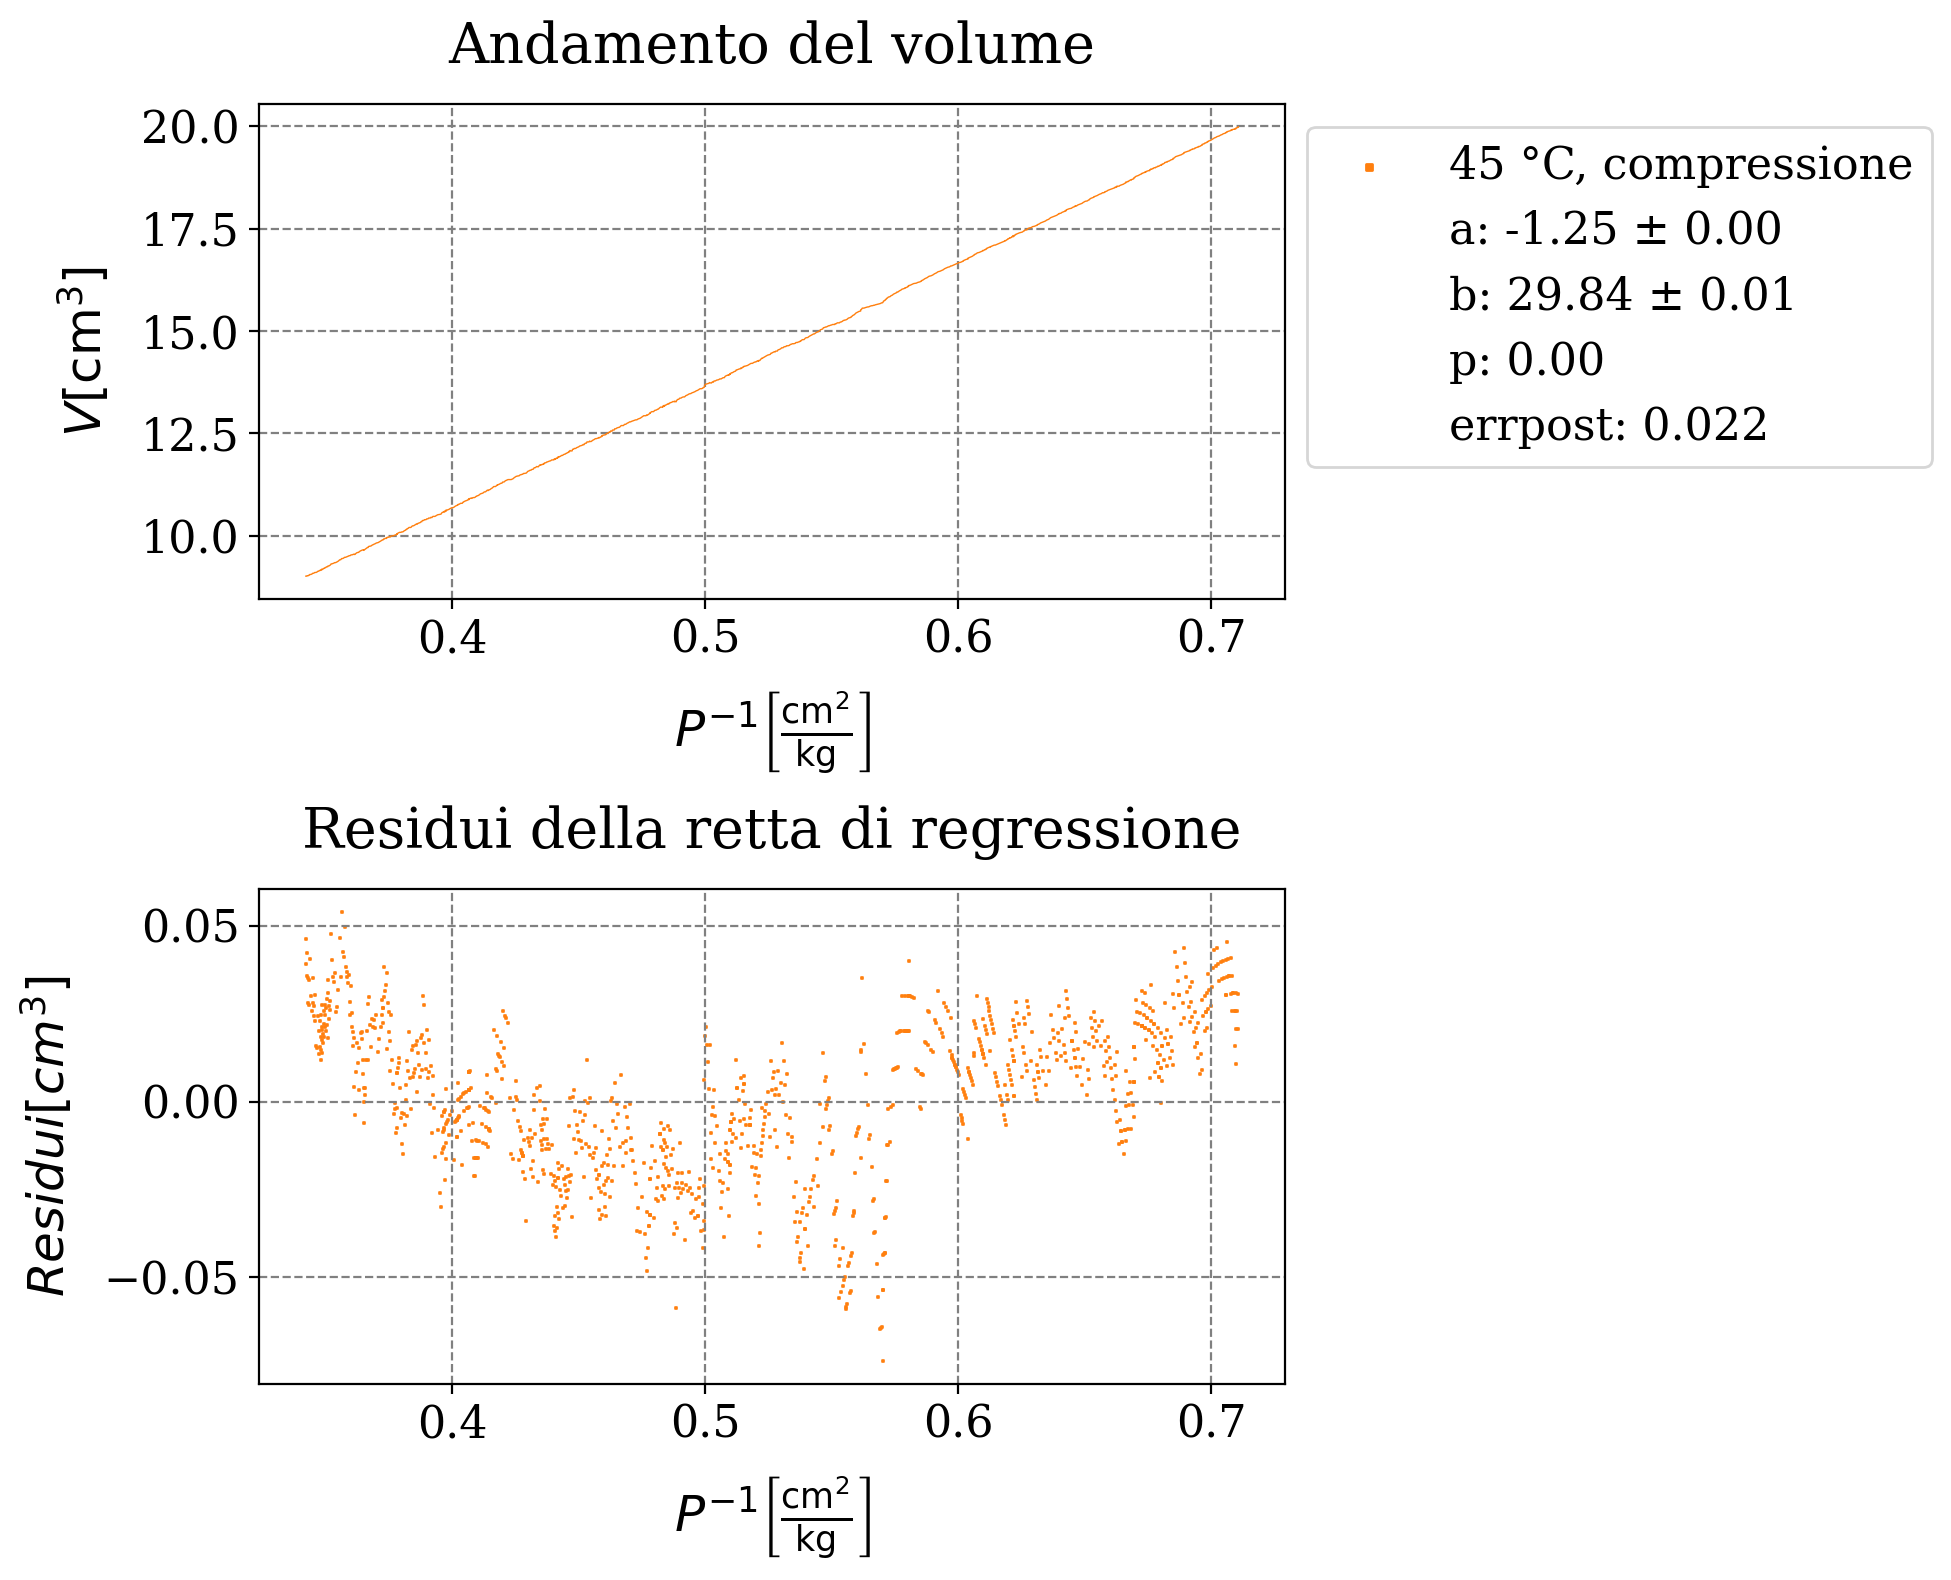

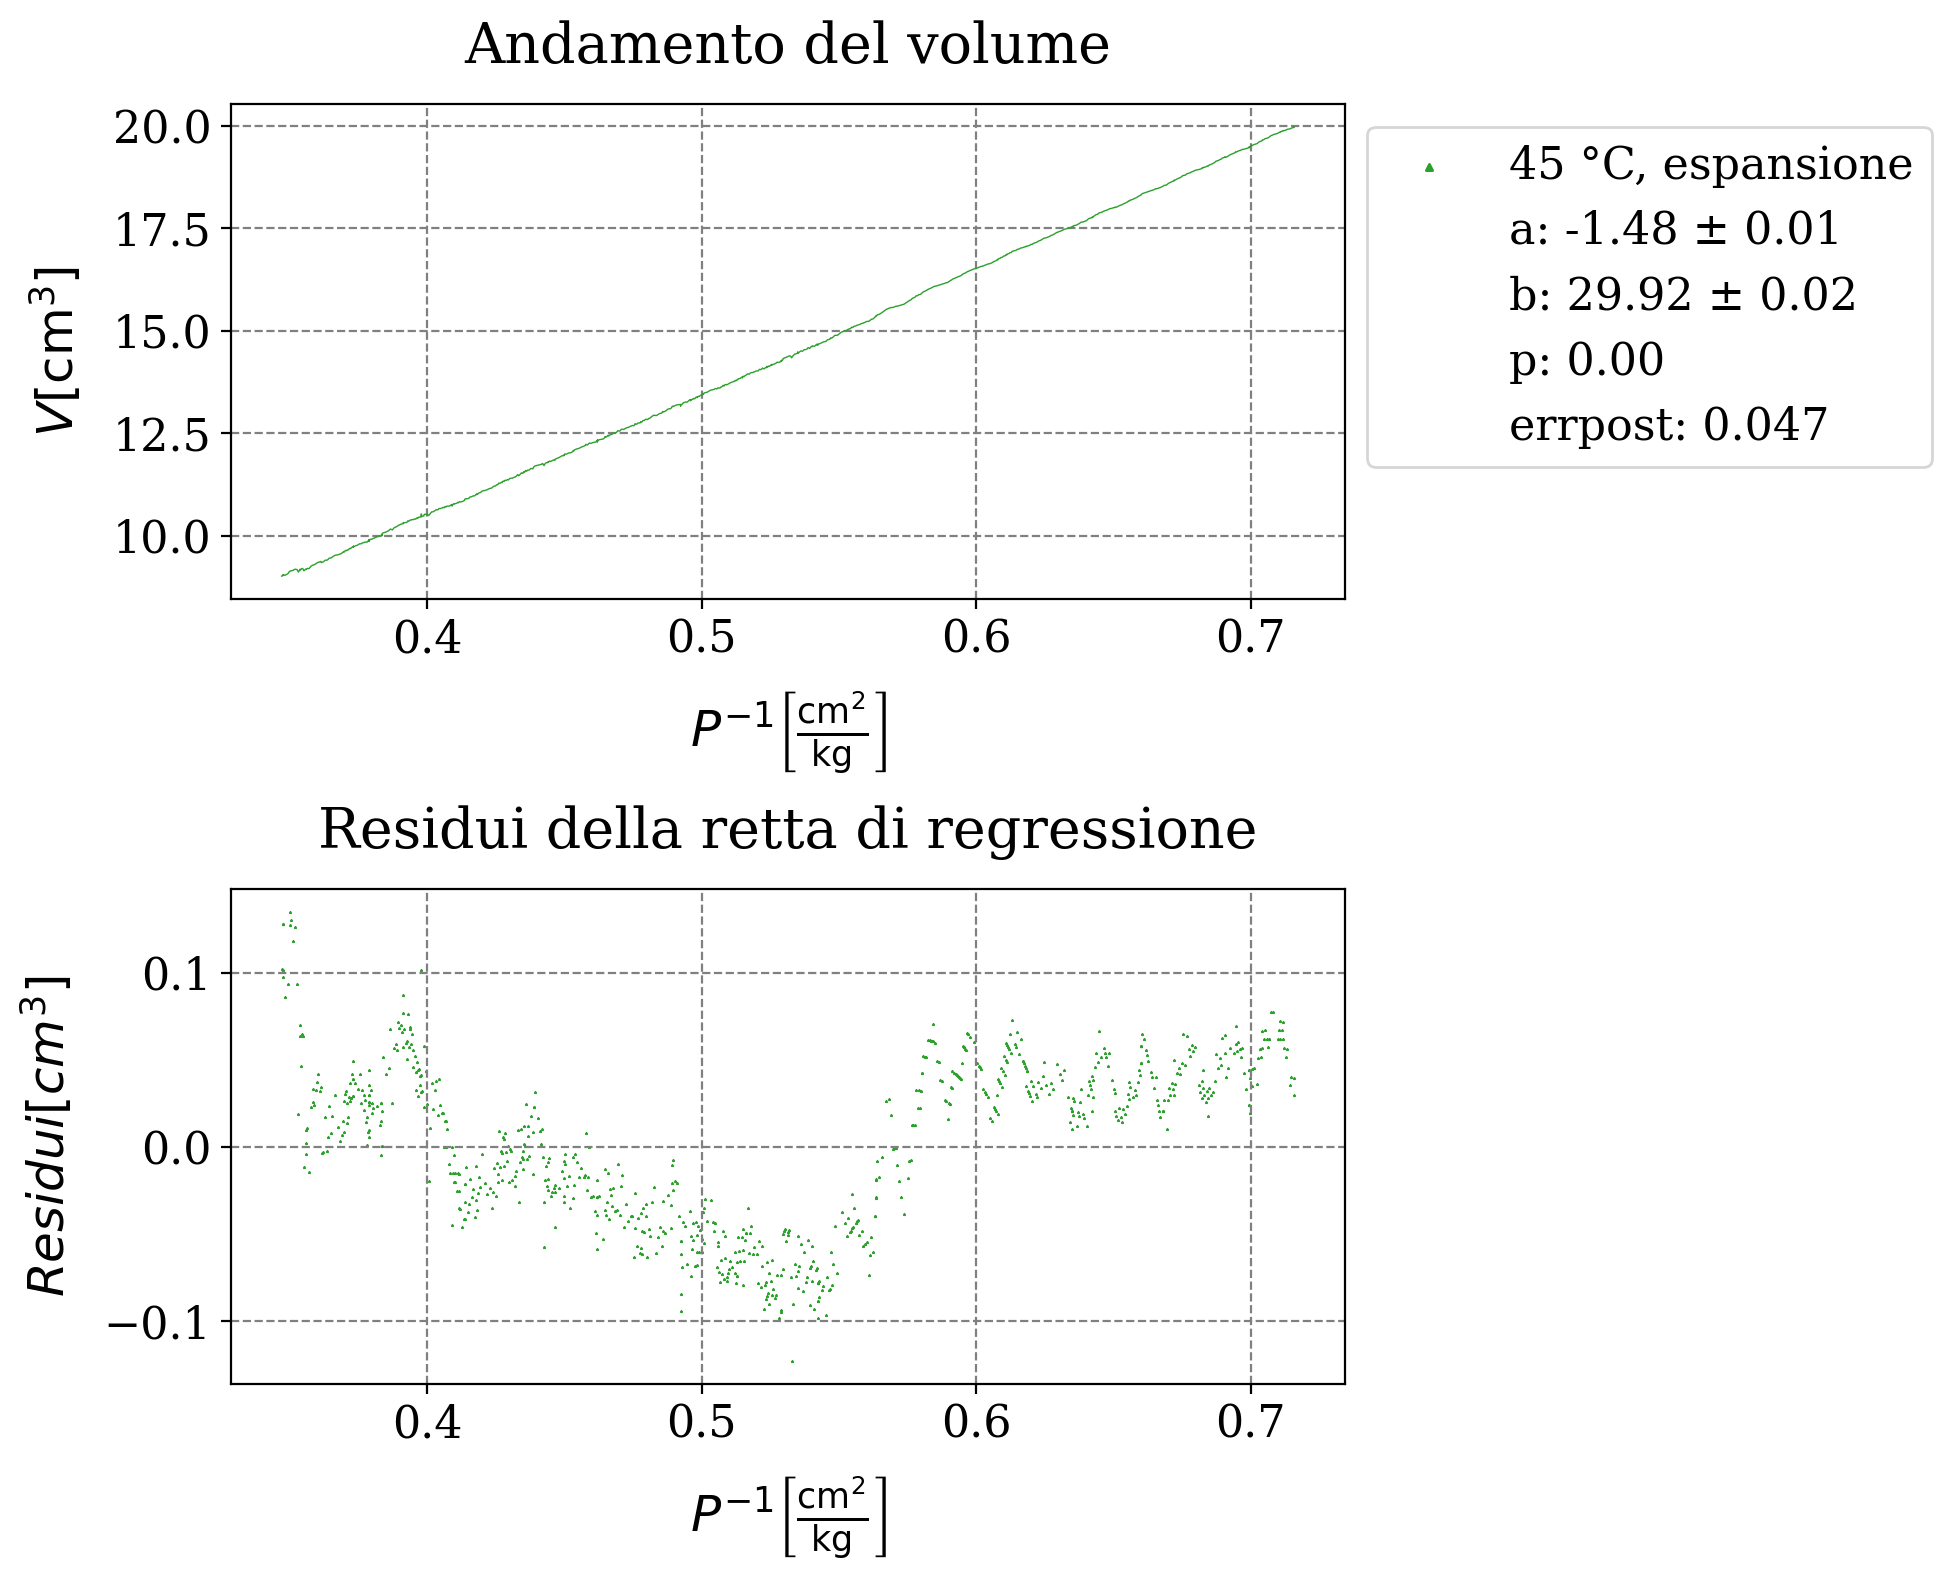

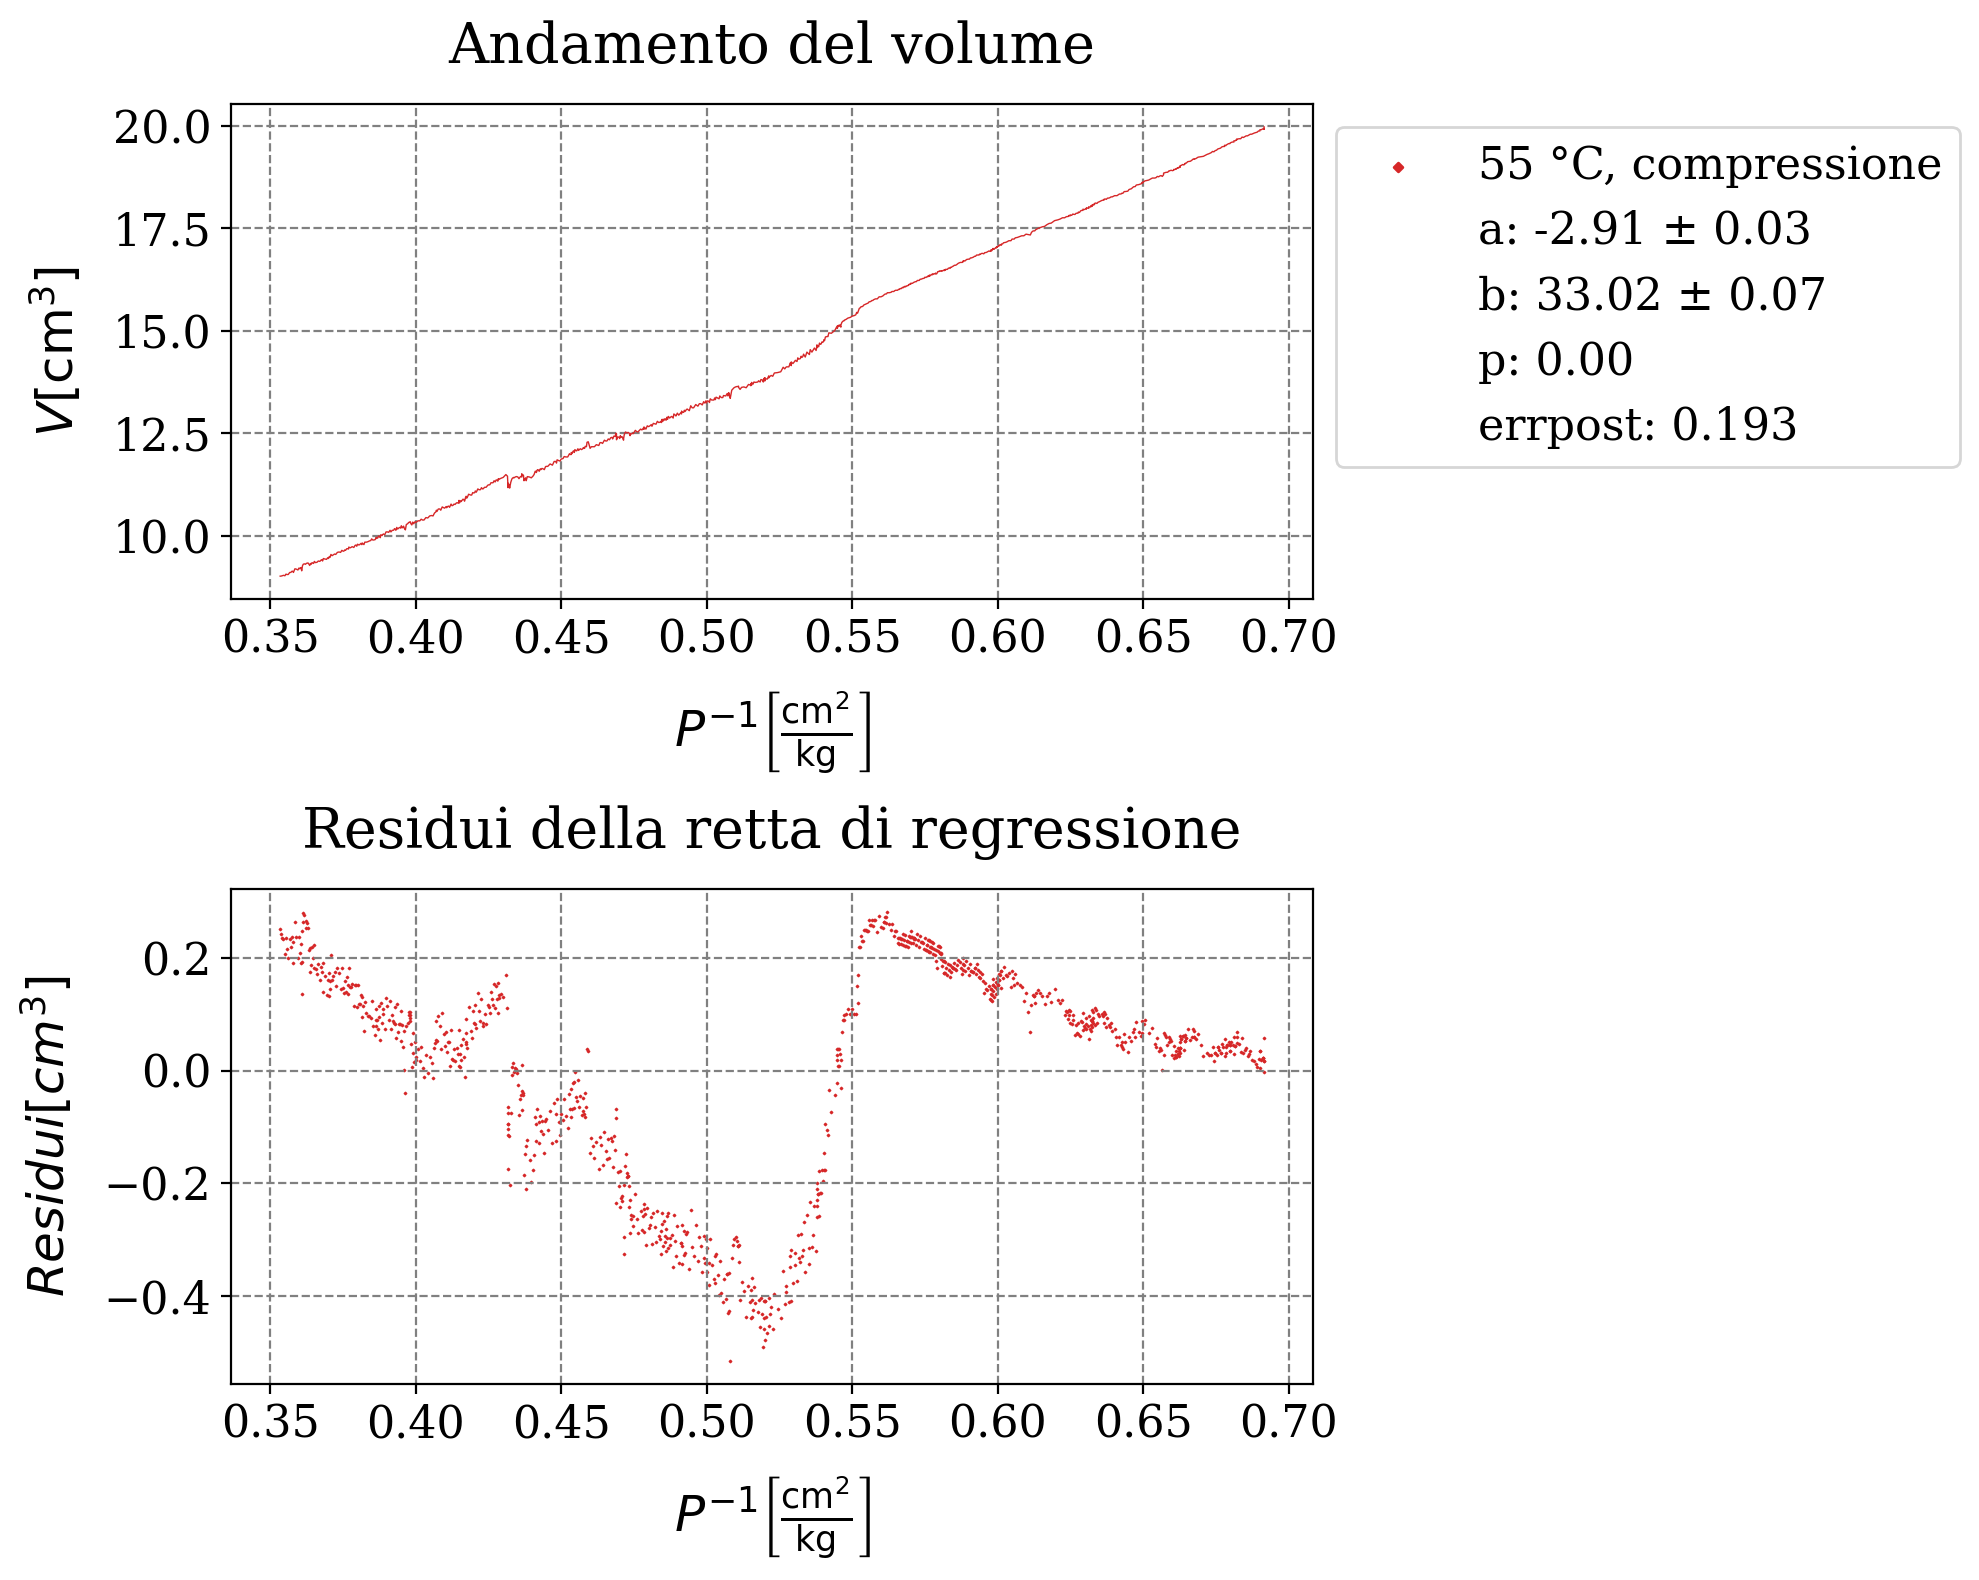

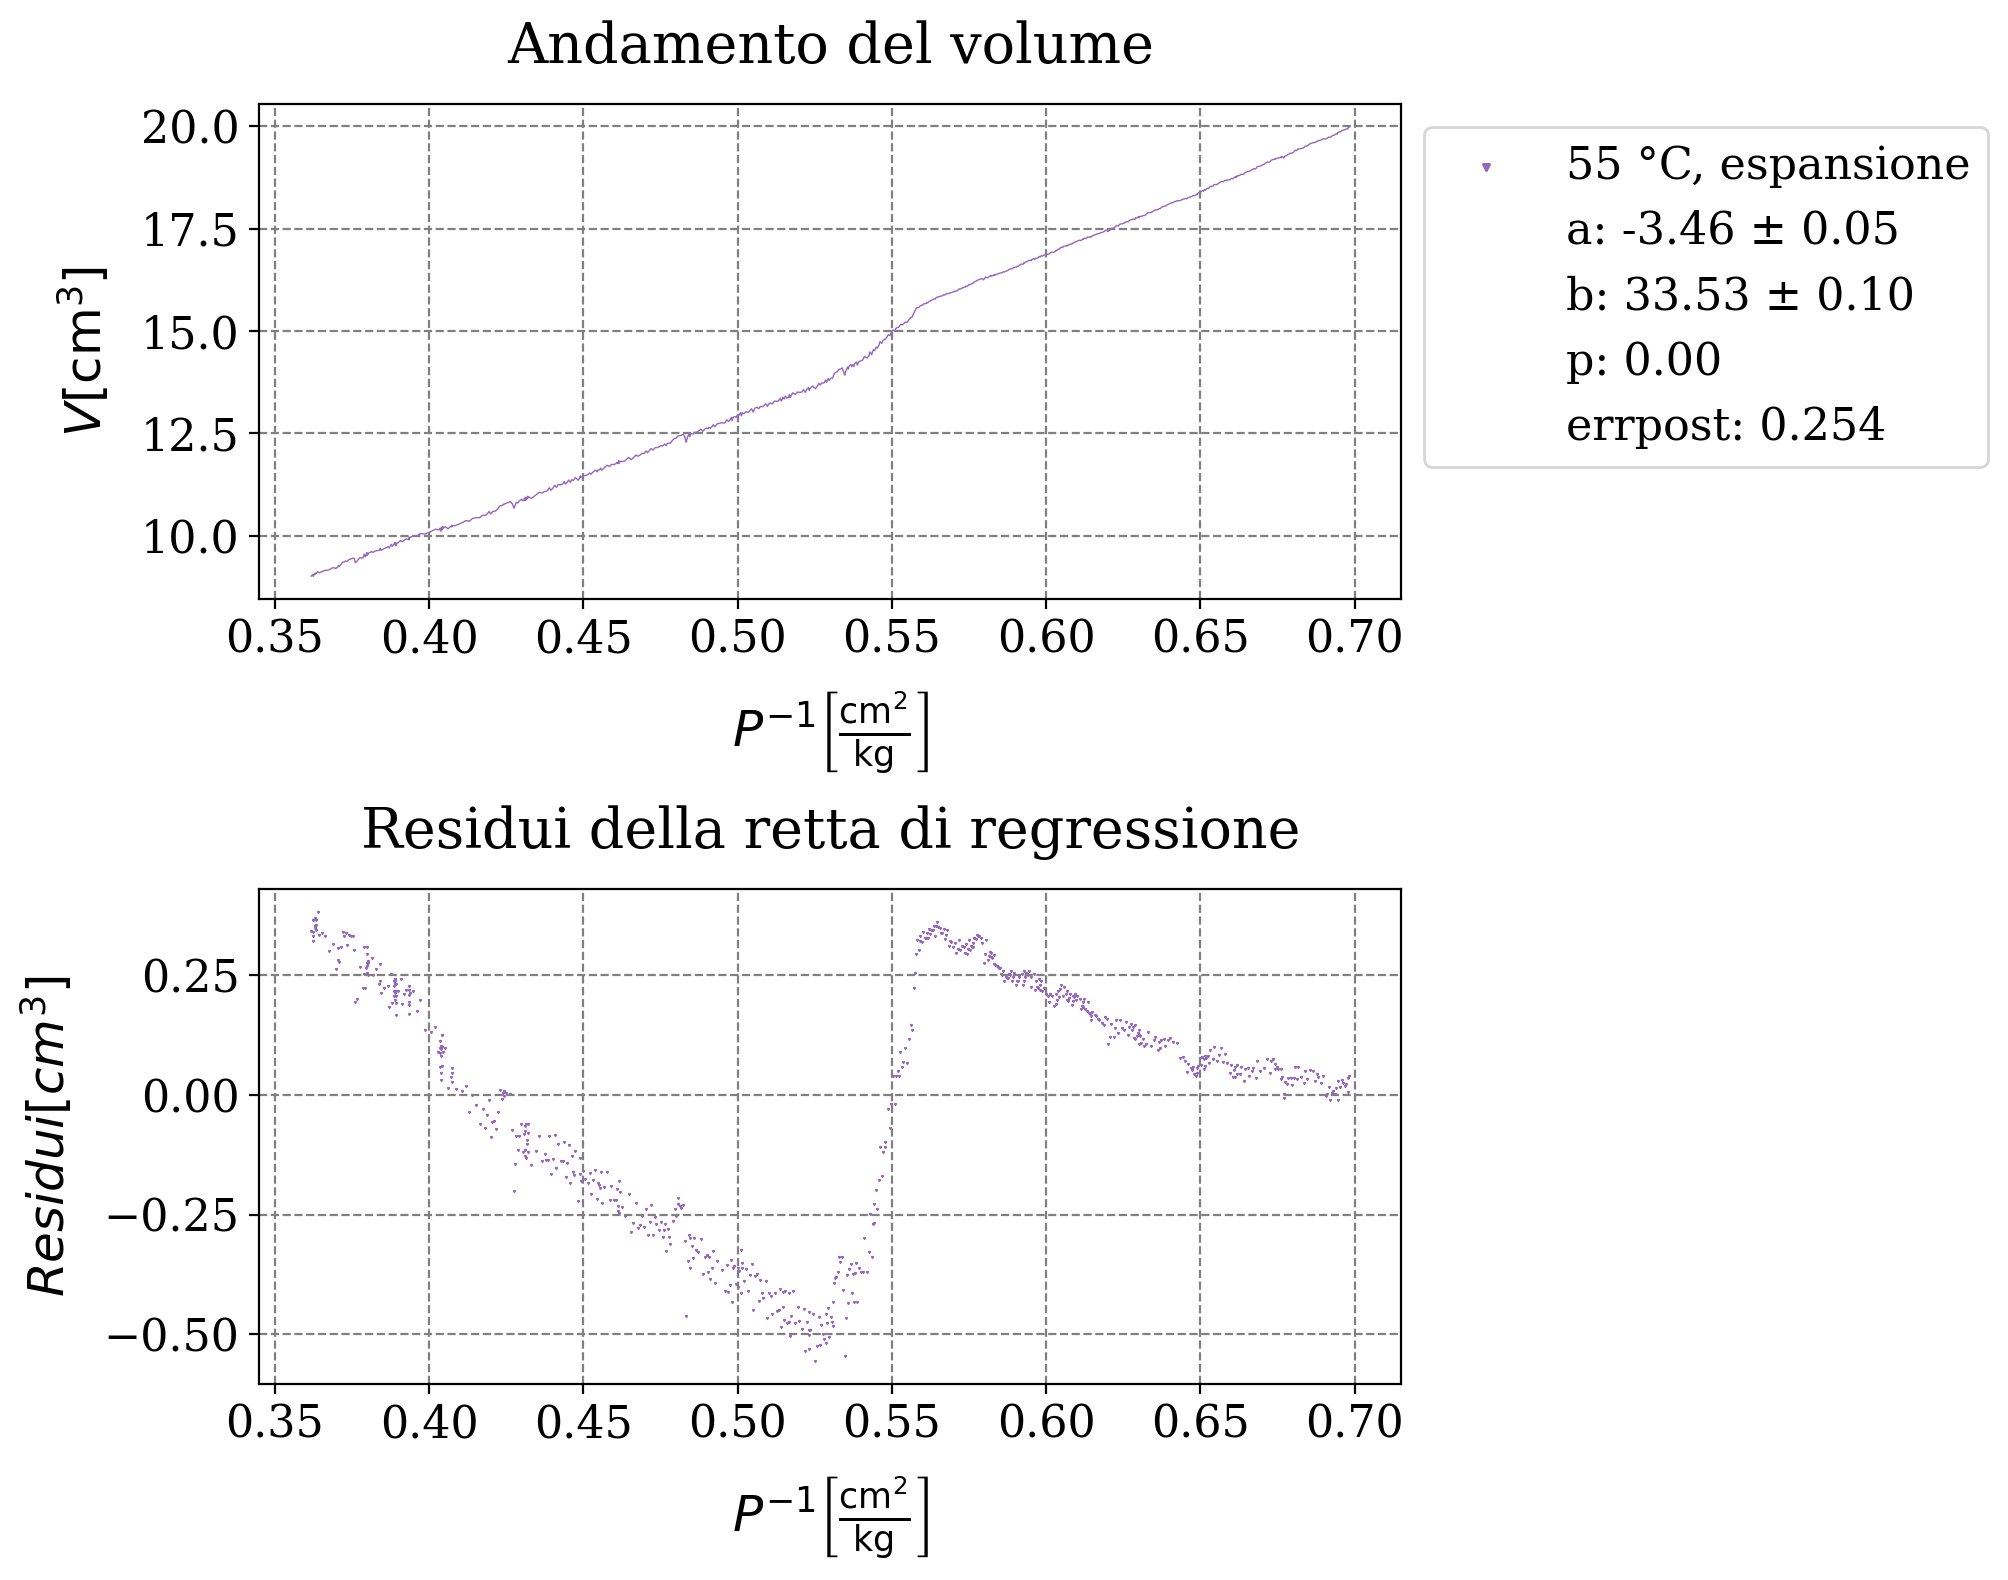

In [16]:
grafico_serie(dati, directory, color_cycle, marker_cycle, parametri)

# 3. Eliminazione Picchi

Vengono eliminati i picchi, ma solo nella serie che contiene il picco. Serve eliminare direttamente quella fascia in tutte le serie di dati?

In [17]:
def taglia_dati(dizionario, estremo, parametri):
    dati_tagliati = {}

    for temp, serie in dizionario.items():
        dati_tagliati[temp] = {}

        for fase_chiave, fase in serie.items():
            a = parametri[temp][fase_chiave]["a"]
            b = parametri[temp][fase_chiave]["b"]

            # Calcolo dei residui
            residui = np.array([y - (a + b * 1/x) for y, x in zip(fase["V"], fase["P"])])

            # Taglio dei dati: mantieni solo dove |V| < estremo
            maschera = np.abs(residui) < estremo

            # Salvataggio nei dati tagliati
            dati_tagliati[temp][fase_chiave] = {
                'P': fase['P'][maschera],
                'V': fase['V'][maschera],
                'T': fase['T'][maschera],
            }
    
    return dati_tagliati

Funzione che incorpora tutto il processo

In [18]:
def taglio(dati, parametri, estremo, directory, input_files, color_cycle, marker_cycle, serie=False):

    if not os.path.exists("./Elaborati/" + directory):
        os.mkdir("./Elaborati/" + directory)
    if not os.path.exists("./Images/" + directory):
        os.mkdir("./Images/" + directory)
        
    dati_tagliati = taglia_dati(dati, estremo, parametri)

    parametri_tagliati = regressione(dati_tagliati, directory, input_files)

    grafico_residui(dati_tagliati, directory, color_cycle, marker_cycle, parametri_tagliati)

    if serie:
        grafico_serie(dati_tagliati, directory, color_cycle, marker_cycle, parametri_tagliati)
    
    return dati_tagliati, parametri_tagliati

## 3.1 Tagli

### 3.1.1 Taglio 1


Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3


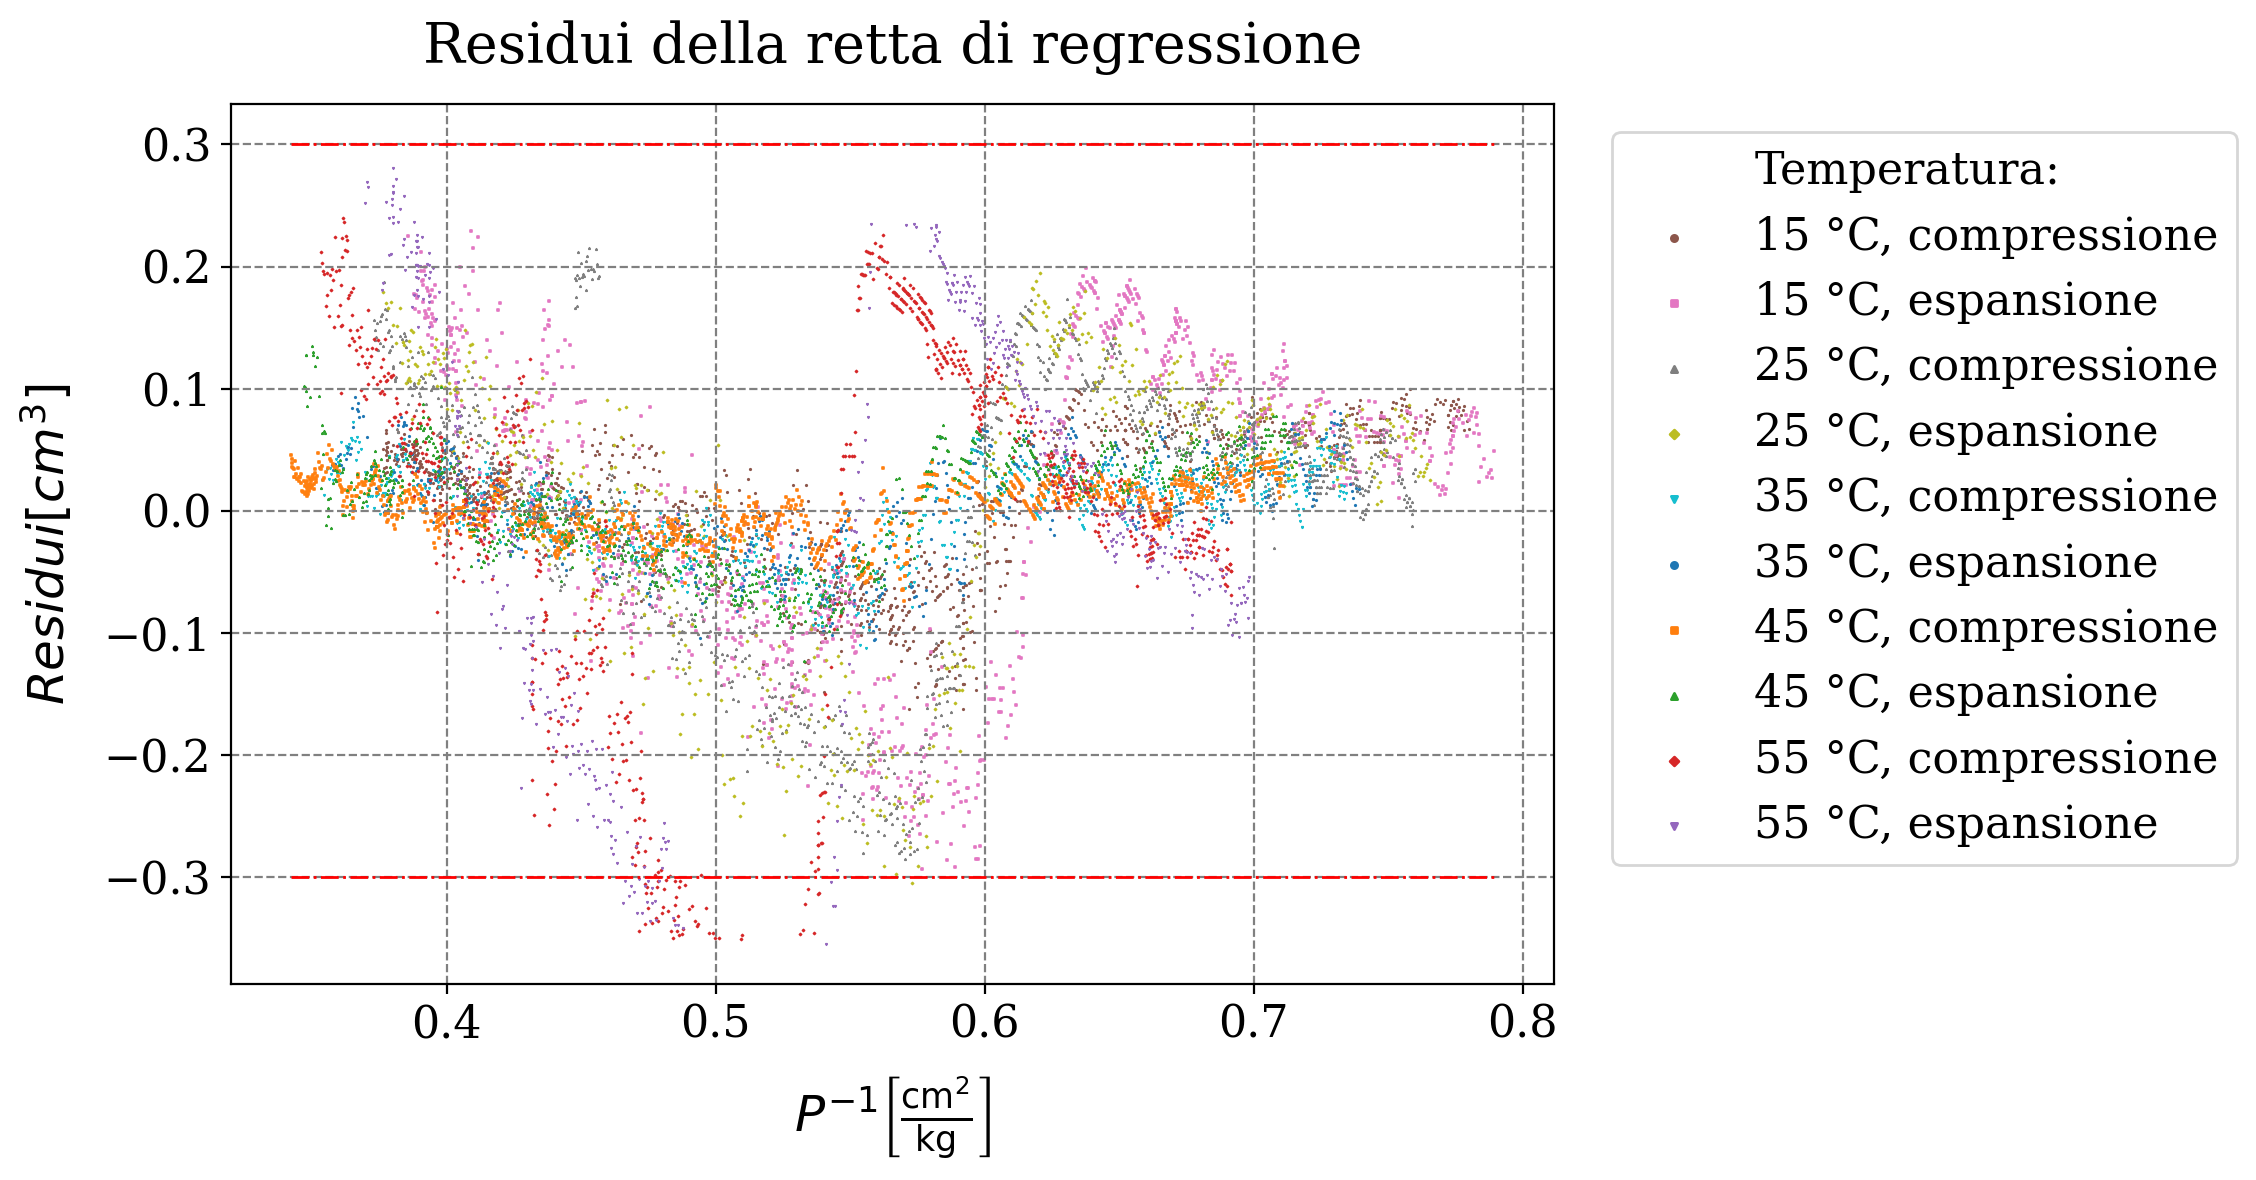

In [19]:
directory = "Taglio1"
dati1, parametri1 = taglio(dati, parametri, estremo, directory, input_files, color_cycle, marker_cycle)

### 3.1.2 Taglio 2


Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3


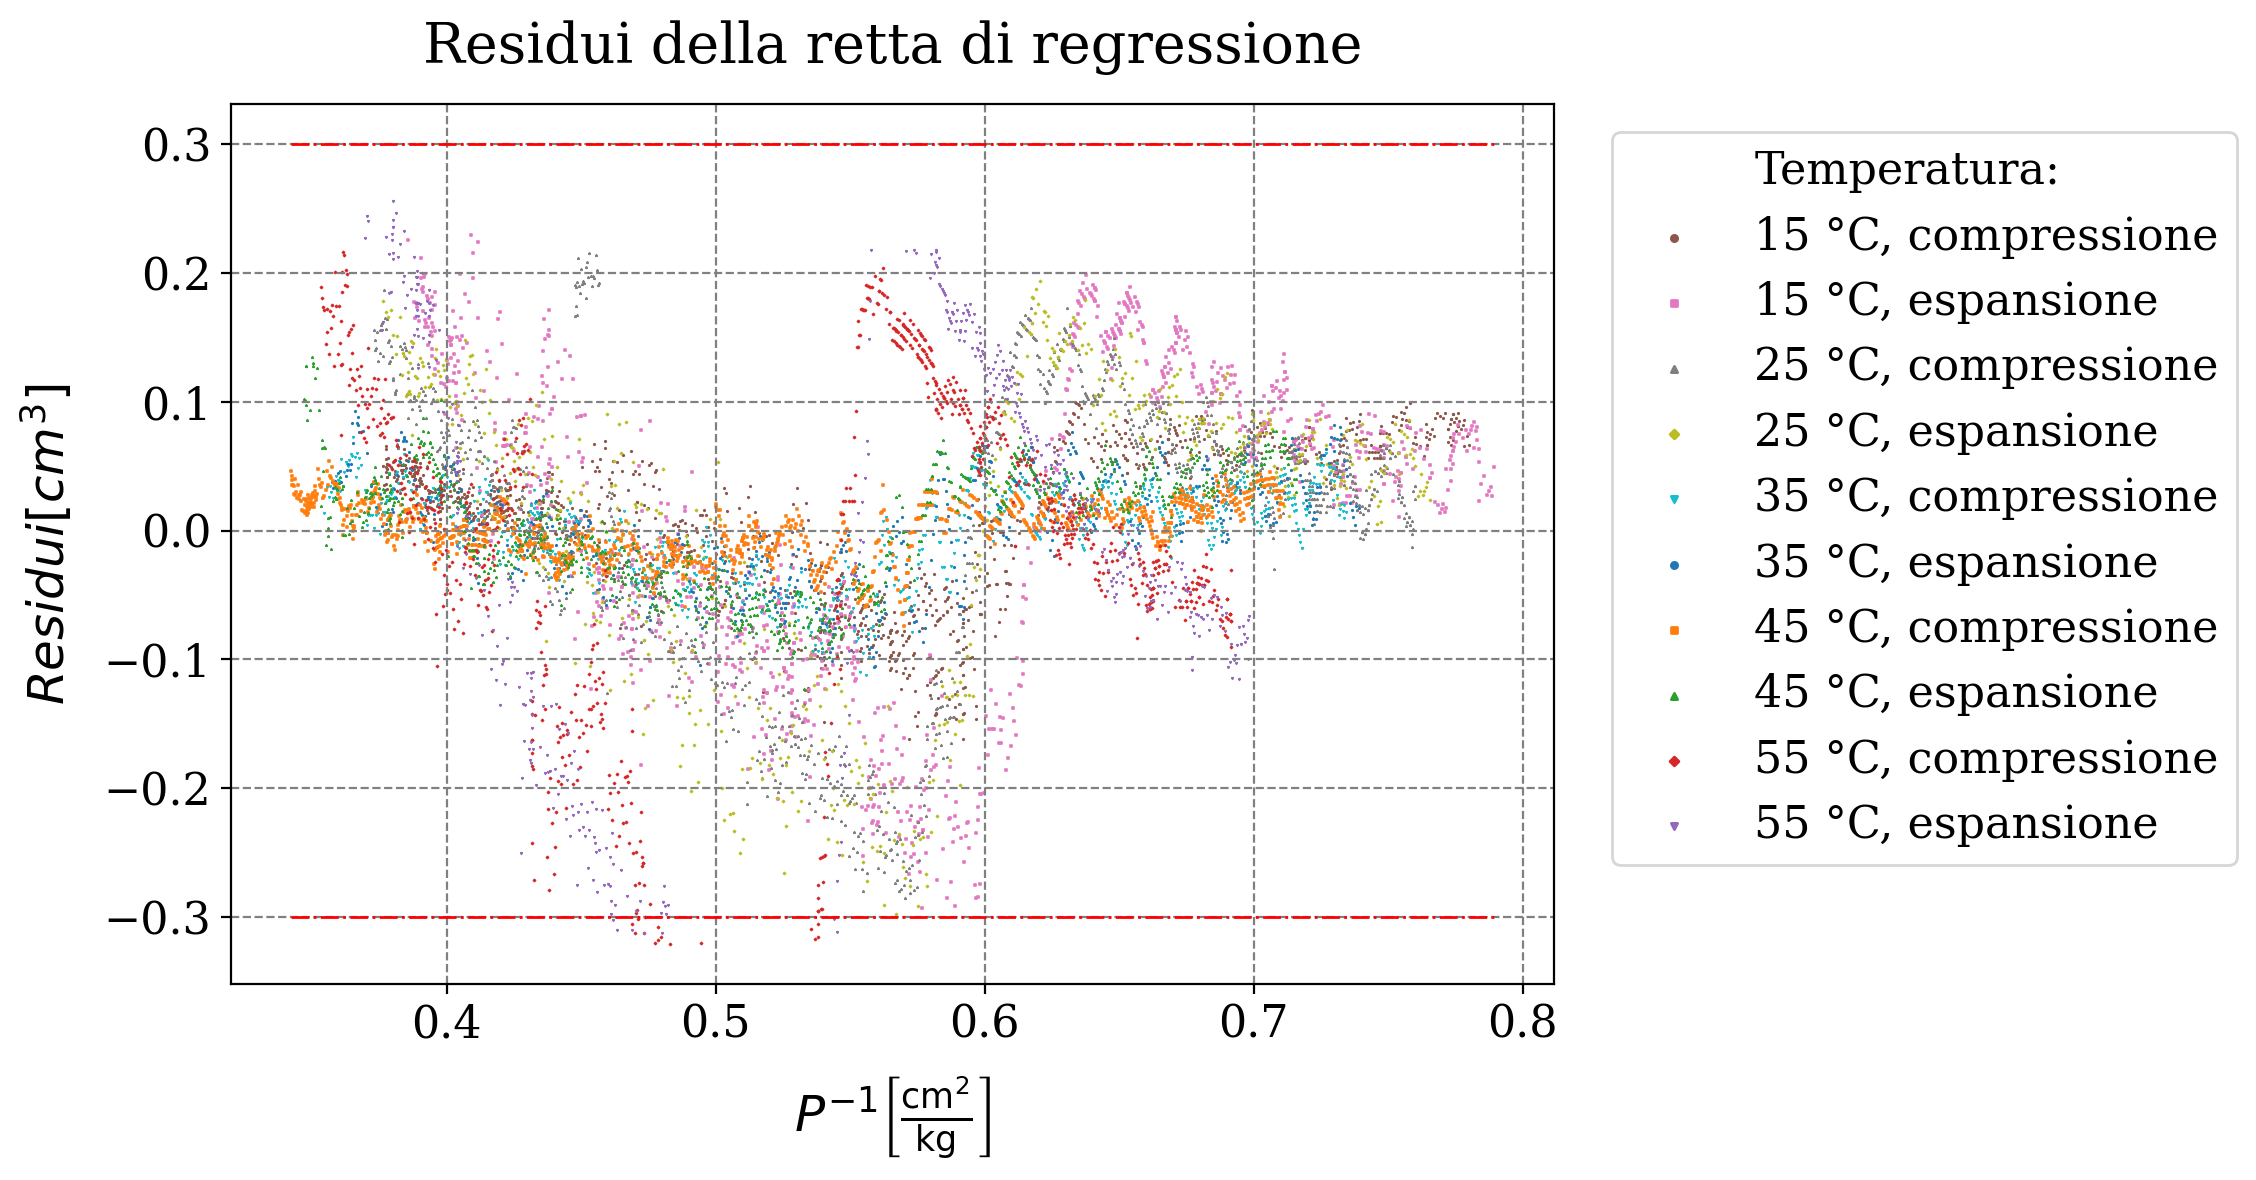

In [20]:
directory = "Taglio2"
dati2,parametri2 = taglio(dati1, parametri1, estremo, directory, input_files, color_cycle, marker_cycle)

### 3.1.3 Taglio 3


Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 15
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 25
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 35
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 45
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x uniformi
	Incertezze y uniformi
	Minimi quadrati 3

Elaborazione serie 55
	Incertezze x variabili
	Incertezze y uniformi
	Minimi quadrati 3


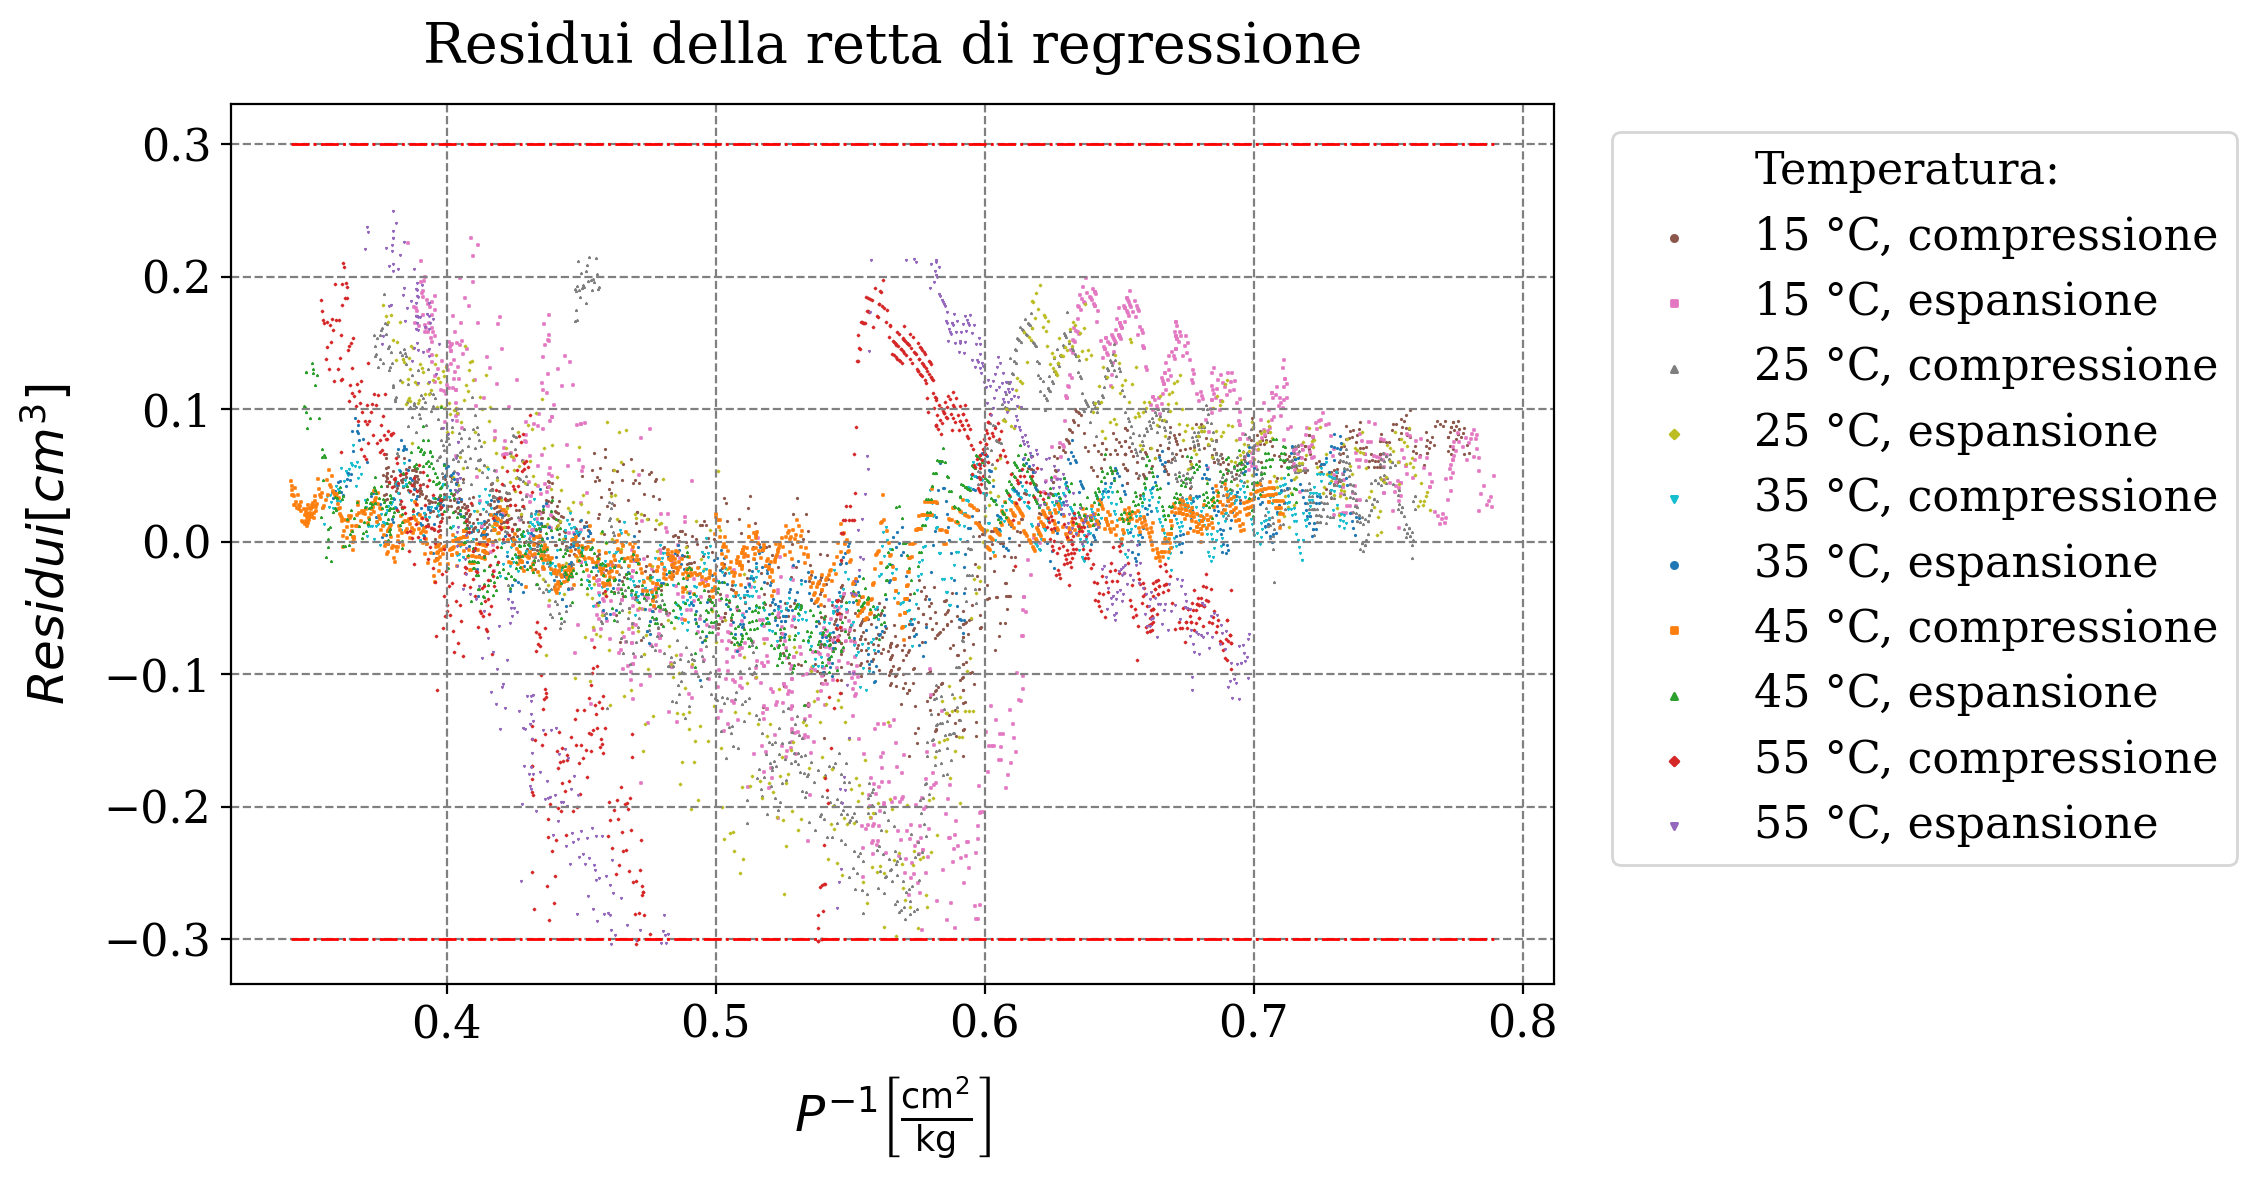

In [21]:
directory = "Taglio3"
dati3,parametri3 = taglio(dati2, parametri2, estremo, directory, input_files, color_cycle, marker_cycle)

## 3.2 Conclusioni

I residui sono entro la tolleranza e pertanto la legge di Boyle risulta verificata. Serve usare un chi quadro? L'andamento dei residui definisce una sorta di S nella forma dei dati rispetto alla legge, è dovuto alla velocità con cui è stata girata la manovella?

## 3.3 Residui Compressione e Espansione

## 3.4 Testo per Leonardo

In [22]:
os.mkdir("./Leonardo")
for temp, serie in dati3.items():
    for fase_chiave, fase in serie.items():
        open(f"./Leonardo/{temp}_{fase_chiave}.txt", "w").close()
        with open(f"./Leonardo/{temp}_{fase_chiave}.txt", "a") as file:
            for P, V, T in zip(fase["P"], fase["V"], fase["T"]):
                file.write(f"{P:.3f} {V:.2f} {T:.2f}\n")